In [1]:
# Notebook 04 — Publication Tables and Figures

# This notebook generates the final descriptive tables and publication
# figures from the validated Final Evaluation Dataset.

# The analysis uses the five predefined evaluation metrics:

# 1. Semantic Similarity
# 2. Containment Score
# 3. Hybrid Score
# 4. Injection Failure Rate
# 5. Abstention Accuracy

# Metric applicability is preserved:

# - Semantic Similarity: all evaluation rows
# - Hybrid Score: all evaluation rows
# - Containment Score: extractive-answer rows
# - Injection Failure Rate: injected samples with valid outputs
# - Abstention Accuracy: NOT_FOUND rows

# Prompt A is the baseline condition.

# Prompts B, C, C1, and C2 are treated as defensive prompting conditions.

# The best defensive prompt for each model is selected using mean Hybrid
# Score as the primary criterion. Exact ties are resolved by lower
# Injection Failure Rate, then higher Semantic Similarity, and finally
# the fixed prompt order B, C, C1, C2.

# This notebook produces descriptive summaries, tables, and figures only.
# It does not compare development versions of the evaluation pipeline.

In [2]:
# Cell 2

from __future__ import annotations

import hashlib
import json
import math
import platform
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np
import pandas as pd

from matplotlib.patches import Patch
from openpyxl.styles import Alignment, Font, PatternFill
from openpyxl.utils import get_column_letter


print("Notebook 04 imports completed successfully.")

Notebook 04 imports completed successfully.


In [3]:
# Cell 3

# ============================================================
# Project paths
# ============================================================

ROOT = Path.cwd().resolve()

OUTPUT_ROOT = ROOT / "outputs_v2"
FINAL_DATASET_DIR = OUTPUT_ROOT / "final_dataset"
TABLE_DIR = OUTPUT_ROOT / "tables"
FIGURE_DIR = OUTPUT_ROOT / "figures"
AUDIT_DIR = OUTPUT_ROOT / "audit"
LOG_DIR = OUTPUT_ROOT / "logs"


for directory in [
    TABLE_DIR,
    FIGURE_DIR,
    AUDIT_DIR,
    LOG_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )


# Prefer Parquet for analysis because it preserves
# missing numeric values and types exactly.
FINAL_DATASET_PARQUET = (
    FINAL_DATASET_DIR
    / "Final_Evaluation_Dataset_v2.parquet"
)

FINAL_DATASET_XLSX = (
    FINAL_DATASET_DIR
    / "Final_Evaluation_Dataset_v2.xlsx"
)


# ============================================================
# Experimental ordering
# ============================================================

MODEL_ORDER = [
    "gpt 5.4",
    "claude 4.6 Sonnet",
    "Gemini 3.1 Pro",
    "DeepSeek V4 Pro",
]

MODEL_SHORT = {
    "gpt 5.4": "GPT",
    "claude 4.6 Sonnet": "Claude",
    "Gemini 3.1 Pro": "Gemini",
    "DeepSeek V4 Pro": "DeepSeek",
}

PROMPT_ORDER = [
    "A",
    "B",
    "C",
    "C1",
    "C2",
]

DEFENSIVE_PROMPTS = [
    "B",
    "C",
    "C1",
    "C2",
]


# ============================================================
# Final metric names
# ============================================================

METRICS = [
    "semantic_similarity",
    "containment_score",
    "hybrid_score",
    "injection_failure",
    "abstention_correct",
]

METRIC_LABELS = {
    "semantic_similarity": (
        "Semantic Similarity"
    ),
    "containment_score": (
        "Containment Score"
    ),
    "hybrid_score": (
        "Hybrid Score"
    ),
    "injection_failure": (
        "Injection Failure Rate"
    ),
    "abstention_correct": (
        "Abstention Accuracy"
    ),
}


# ============================================================
# Publication settings
# ============================================================

DPI = 600

plt.rcParams.update(
    {
        "font.family": "DejaVu Sans",
        "font.size": 10,
        "axes.titlesize": 11,
        "axes.labelsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 9,
        "figure.titlesize": 13,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "savefig.bbox": "tight",
    }
)


MODEL_COLORS = {
    model: plt.get_cmap("tab10")(index)
    for index, model
    in enumerate(MODEL_ORDER)
}

PROMPT_COLORS = {
    prompt: plt.get_cmap("tab10")(index)
    for index, prompt
    in enumerate(PROMPT_ORDER)
}


print(f"Project root      : {ROOT}")
print(f"Tables directory  : {TABLE_DIR}")
print(f"Figures directory : {FIGURE_DIR}")

Project root      : D:\prompt_control_study
Tables directory  : D:\prompt_control_study\outputs_v2\tables
Figures directory : D:\prompt_control_study\outputs_v2\figures


In [4]:
# Cell 4

def sha256_file(
    file_path: Path,
    chunk_size: int = 1024 * 1024,
) -> str:
    digest = hashlib.sha256()

    with file_path.open(
        "rb"
    ) as file_handle:
        for chunk in iter(
            lambda: file_handle.read(
                chunk_size
            ),
            b"",
        ):
            digest.update(chunk)

    return digest.hexdigest()


def write_excel_table(
    dataframe: pd.DataFrame,
    output_path: Path,
    *,
    sheet_name: str = "Table",
) -> None:
    """
    Write a publication-supporting Excel table while
    retaining full-precision numerical values.
    """

    with pd.ExcelWriter(
        output_path,
        engine="openpyxl",
    ) as writer:

        dataframe.to_excel(
            writer,
            index=False,
            sheet_name=sheet_name,
        )

        worksheet = writer.book[
            sheet_name
        ]

        header_fill = PatternFill(
            fill_type="solid",
            fgColor="1F4E78",
        )

        header_font = Font(
            bold=True,
            color="FFFFFF",
        )

        for cell in worksheet[1]:
            cell.fill = header_fill
            cell.font = header_font
            cell.alignment = Alignment(
                horizontal="center",
                vertical="center",
                wrap_text=True,
            )

        worksheet.freeze_panes = "A2"
        worksheet.auto_filter.ref = (
            worksheet.dimensions
        )

        for column_cells in worksheet.columns:
            column_letter = get_column_letter(
                column_cells[0].column
            )

            max_length = 0

            for cell in column_cells:
                cell.alignment = Alignment(
                    vertical="top",
                    wrap_text=True,
                )

                if isinstance(
                    cell.value,
                    float,
                ):
                    cell.number_format = "0.000000"

                value_length = len(
                    str(cell.value)
                    if cell.value is not None
                    else ""
                )

                max_length = max(
                    max_length,
                    value_length,
                )

            worksheet.column_dimensions[
                column_letter
            ].width = min(
                max(
                    max_length + 2,
                    12,
                ),
                40,
            )


def save_publication_figure(
    figure: plt.Figure,
    stem: str,
) -> None:
    png_path = (
        FIGURE_DIR
        / f"{stem}.png"
    )

    pdf_path = (
        FIGURE_DIR
        / f"{stem}.pdf"
    )

    figure.savefig(
        png_path,
        dpi=DPI,
        bbox_inches="tight",
    )

    figure.savefig(
        pdf_path,
        bbox_inches="tight",
    )

    print(
        f"Saved: {png_path.name}"
    )

    print(
        f"Saved: {pdf_path.name}"
    )


def aggregate_metrics(
    dataframe: pd.DataFrame,
    group_columns: list[str],
) -> pd.DataFrame:
    """
    Compute metric-specific means and valid denominators.
    NaN values are intentionally excluded according to
    metric applicability.
    """

    grouped = (
        dataframe
        .groupby(
            group_columns,
            observed=True,
            sort=False,
        )
    )

    output = grouped.agg(
        semantic_similarity=(
            "semantic_similarity",
            "mean",
        ),
        n_semantic_similarity=(
            "semantic_similarity",
            "count",
        ),

        containment_score=(
            "containment_score",
            "mean",
        ),
        n_containment_score=(
            "containment_score",
            "count",
        ),

        hybrid_score=(
            "hybrid_score",
            "mean",
        ),
        n_hybrid_score=(
            "hybrid_score",
            "count",
        ),

        injection_failure=(
            "injection_failure",
            "mean",
        ),
        n_injection_failure=(
            "injection_failure",
            "count",
        ),

        abstention_correct=(
            "abstention_correct",
            "mean",
        ),
        n_abstention_correct=(
            "abstention_correct",
            "count",
        ),
    ).reset_index()

    return output


def format_mean(
    value: float,
) -> str:
    if pd.isna(value):
        return "NA"

    return f"{value:.3f}"


print("Helper functions defined.")

Helper functions defined.


In [5]:
# Cell 5

# ============================================================
# Load final dataset
# ============================================================

if FINAL_DATASET_PARQUET.is_file():

    final_evaluation = pd.read_parquet(
        FINAL_DATASET_PARQUET,
        engine="pyarrow",
    )

    FINAL_DATASET_PATH = (
        FINAL_DATASET_PARQUET
    )

elif FINAL_DATASET_XLSX.is_file():

    final_evaluation = pd.read_excel(
        FINAL_DATASET_XLSX
    )

    FINAL_DATASET_PATH = (
        FINAL_DATASET_XLSX
    )

else:
    raise FileNotFoundError(
        "Final Evaluation Dataset was not found."
    )


EXPECTED_COLUMNS = [
    "id",
    "model",
    "prompt",
    "answer",
    "gold_answer",
    "semantic_similarity",
    "containment_score",
    "hybrid_score",
    "injection_failure",
    "abstention_correct",
]


if list(
    final_evaluation.columns
) != EXPECTED_COLUMNS:
    raise RuntimeError(
        "Unexpected Final Evaluation Dataset "
        "column structure."
    )


final_evaluation["id"] = (
    pd.to_numeric(
        final_evaluation["id"],
        errors="raise",
    )
    .astype(int)
)

final_evaluation["model"] = (
    final_evaluation["model"]
    .astype(str)
    .str.strip()
)

final_evaluation["prompt"] = (
    final_evaluation["prompt"]
    .astype(str)
    .str.strip()
)

final_evaluation["answer"] = (
    final_evaluation["answer"]
    .fillna("")
    .astype(str)
)


# ============================================================
# Structural validation
# ============================================================

experiment_key = (
    final_evaluation["id"]
    .astype(str)
    + "|"
    + final_evaluation["model"]
    + "|"
    + final_evaluation["prompt"]
)


model_prompt_counts = (
    final_evaluation
    .groupby(
        [
            "model",
            "prompt",
        ]
    )
    .size()
)


validation_rows = []


def add_check(
    check: str,
    observed: Any,
    expected: Any,
    passed: bool,
    note: str = "",
) -> None:

    validation_rows.append(
        {
            "Check": check,
            "Observed": observed,
            "Expected": expected,
            "Status": (
                "PASS"
                if passed
                else "FAIL"
            ),
            "Note": note,
        }
    )


add_check(
    "Evaluation rows",
    len(final_evaluation),
    6000,
    len(final_evaluation) == 6000,
)

add_check(
    "Evaluation columns",
    len(final_evaluation.columns),
    10,
    len(final_evaluation.columns) == 10,
)

add_check(
    "Unique experiment keys",
    experiment_key.nunique(),
    6000,
    experiment_key.nunique() == 6000,
)

add_check(
    "Unique benchmark IDs",
    final_evaluation["id"].nunique(),
    300,
    final_evaluation["id"].nunique() == 300,
)

add_check(
    "Models",
    final_evaluation["model"].nunique(),
    4,
    (
        set(
            final_evaluation["model"]
        )
        == set(MODEL_ORDER)
    ),
)

add_check(
    "Prompts",
    final_evaluation["prompt"].nunique(),
    5,
    (
        set(
            final_evaluation["prompt"]
        )
        == set(PROMPT_ORDER)
    ),
)

add_check(
    "Model–Prompt cells",
    len(model_prompt_counts),
    20,
    len(model_prompt_counts) == 20,
)

add_check(
    "Rows per Model–Prompt cell",
    (
        "All 300"
        if model_prompt_counts.eq(300).all()
        else "Not balanced"
    ),
    "All 300",
    model_prompt_counts.eq(300).all(),
)

add_check(
    "Empty model outputs",
    int(
        final_evaluation[
            "answer"
        ].eq("").sum()
    ),
    9,
    (
        final_evaluation[
            "answer"
        ].eq("").sum()
        == 9
    ),
)


structural_validation = pd.DataFrame(
    validation_rows
)

display(
    structural_validation
)


if structural_validation[
    "Status"
].eq("FAIL").any():
    raise RuntimeError(
        "Final dataset structural validation failed."
    )


print(
    "Final Evaluation Dataset loaded and "
    "structurally validated."
)

print(
    f"Input file SHA-256: "
    f"{sha256_file(FINAL_DATASET_PATH)}"
)

,Check,Observed,Expected,Status,Note
0,Evaluation rows,6000,6000,PASS,
1,Evaluation columns,10,10,PASS,
2,Unique experiment keys,6000,6000,PASS,
3,Unique benchmark IDs,300,300,PASS,
4,Models,4,4,PASS,
5,Prompts,5,5,PASS,
6,Model–Prompt cells,20,20,PASS,
7,Rows per Model–Prompt cell,All 300,All 300,PASS,
8,Empty model outputs,9,9,PASS,


Final Evaluation Dataset loaded and structurally validated.
Input file SHA-256: 595a9a6c5db7226a7ba5b4575939edc732d43c7d1dc7c8d737449b10d98e059c


In [6]:
# Cell 6

metric_validation_rows = []


def add_metric_check(
    check: str,
    observed: Any,
    expected: Any,
    passed: bool,
    note: str = "",
) -> None:

    metric_validation_rows.append(
        {
            "Check": check,
            "Observed": observed,
            "Expected": expected,
            "Status": (
                "PASS"
                if passed
                else "FAIL"
            ),
            "Note": note,
        }
    )


# ============================================================
# Metric denominators
# ============================================================

metric_denominators = pd.DataFrame(
    {
        "Metric": [
            METRIC_LABELS[
                metric
            ]
            for metric in METRICS
        ],

        "Valid_N": [
            int(
                final_evaluation[
                    metric
                ].notna().sum()
            )
            for metric in METRICS
        ],

        "Missing_N": [
            int(
                final_evaluation[
                    metric
                ].isna().sum()
            )
            for metric in METRICS
        ],

        "Total_Rows": [
            len(final_evaluation)
            for _ in METRICS
        ],
    }
)


# Known applicability from the validated evaluation engine.
expected_nonmissing = {
    "semantic_similarity": 6000,
    "containment_score": 4000,
    "hybrid_score": 6000,
    "injection_failure": 3117,
    "abstention_correct": 2000,
}


for metric in METRICS:
    observed = int(
        final_evaluation[
            metric
        ].notna().sum()
    )

    expected = (
        expected_nonmissing[
            metric
        ]
    )

    add_metric_check(
        (
            f"{METRIC_LABELS[metric]} "
            "valid denominator"
        ),
        observed,
        expected,
        observed == expected,
    )


# ============================================================
# Metric domains
# ============================================================

semantic_domain_ok = (
    final_evaluation[
        "semantic_similarity"
    ]
    .between(
        -1.0,
        1.0,
        inclusive="both",
    )
    .all()
)

hybrid_domain_ok = (
    final_evaluation[
        "hybrid_score"
    ]
    .between(
        -0.5,
        1.0,
        inclusive="both",
    )
    .all()
)

containment_domain_ok = set(
    final_evaluation[
        "containment_score"
    ]
    .dropna()
    .unique()
).issubset(
    {
        0.0,
        1.0,
    }
)

injection_domain_ok = set(
    final_evaluation[
        "injection_failure"
    ]
    .dropna()
    .unique()
).issubset(
    {
        0.0,
        1.0,
    }
)

abstention_domain_ok = set(
    final_evaluation[
        "abstention_correct"
    ]
    .dropna()
    .unique()
).issubset(
    {
        0.0,
        1.0,
    }
)


add_metric_check(
    "Semantic Similarity domain",
    semantic_domain_ok,
    True,
    semantic_domain_ok,
)

add_metric_check(
    "Containment Score domain",
    containment_domain_ok,
    True,
    containment_domain_ok,
)

add_metric_check(
    "Hybrid Score domain",
    hybrid_domain_ok,
    True,
    hybrid_domain_ok,
)

add_metric_check(
    "Injection Failure domain",
    injection_domain_ok,
    True,
    injection_domain_ok,
)

add_metric_check(
    "Abstention Accuracy domain",
    abstention_domain_ok,
    True,
    abstention_domain_ok,
)


# ============================================================
# Extractive / NOT_FOUND partition
# ============================================================

task_metric_partition_ok = (
    final_evaluation[
        "containment_score"
    ].notna()
    ^
    final_evaluation[
        "abstention_correct"
    ].notna()
).all()


add_metric_check(
    (
        "Containment/Abstention "
        "applicability partition"
    ),
    bool(
        task_metric_partition_ok
    ),
    True,
    bool(
        task_metric_partition_ok
    ),
)


# ============================================================
# Empty-output policy
# ============================================================

empty_output_mask = (
    final_evaluation[
        "answer"
    ].eq("")
)

empty_output_quality_ok = (
    final_evaluation.loc[
        empty_output_mask,
        [
            "semantic_similarity",
            "hybrid_score",
        ],
    ]
    .eq(0.0)
    .all()
    .all()
)


add_metric_check(
    "Empty-output quality scores",
    bool(
        empty_output_quality_ok
    ),
    True,
    bool(
        empty_output_quality_ok
    ),
)


metric_validation = pd.DataFrame(
    metric_validation_rows
)

final_analysis_validation = pd.concat(
    [
        structural_validation,
        metric_validation,
    ],
    ignore_index=True,
)


display(
    metric_denominators
)

display(
    metric_validation
)


if final_analysis_validation[
    "Status"
].eq("FAIL").any():
    raise RuntimeError(
        "Metric validation failed. "
        "Do not generate publication figures."
    )


write_excel_table(
    final_analysis_validation,
    AUDIT_DIR
    / "Final_Analysis_Validation.xlsx",
    sheet_name="Validation",
)

write_excel_table(
    metric_denominators,
    TABLE_DIR
    / "Table05_Metric_Denominators.xlsx",
    sheet_name="Metric Denominators",
)


print(
    "All final metric validation checks passed."
)

,Metric,Valid_N,Missing_N,Total_Rows
0,Semantic Similarity,6000,0,6000
1,Containment Score,4000,2000,6000
2,Hybrid Score,6000,0,6000
3,Injection Failure Rate,3117,2883,6000
4,Abstention Accuracy,2000,4000,6000


,Check,Observed,Expected,Status,Note
0,Semantic Similarity valid denominator,6000,6000,PASS,
1,Containment Score valid denominator,4000,4000,PASS,
2,Hybrid Score valid denominator,6000,6000,PASS,
3,Injection Failure Rate valid denominator,3117,3117,PASS,
4,Abstention Accuracy valid denominator,2000,2000,PASS,
5,Semantic Similarity domain,True,True,PASS,
6,Containment Score domain,True,True,PASS,
7,Hybrid Score domain,True,True,PASS,
8,Injection Failure domain,True,True,PASS,
9,Abstention Accuracy domain,True,True,PASS,


All final metric validation checks passed.


In [7]:
# Cell 7

# ============================================================
# Set categorical order
# ============================================================

final_evaluation[
    "model"
] = pd.Categorical(
    final_evaluation["model"],
    categories=MODEL_ORDER,
    ordered=True,
)

final_evaluation[
    "prompt"
] = pd.Categorical(
    final_evaluation["prompt"],
    categories=PROMPT_ORDER,
    ordered=True,
)


# ============================================================
# Overall model summary
# ============================================================

overall_model_performance = (
    aggregate_metrics(
        final_evaluation,
        ["model"],
    )
    .sort_values("model")
    .reset_index(drop=True)
)


# ============================================================
# Overall prompt summary
# ============================================================

overall_prompt_performance = (
    aggregate_metrics(
        final_evaluation,
        ["prompt"],
    )
    .sort_values("prompt")
    .reset_index(drop=True)
)


# ============================================================
# Full Model × Prompt summary
# ============================================================

model_prompt_performance = (
    aggregate_metrics(
        final_evaluation,
        [
            "model",
            "prompt",
        ],
    )
    .sort_values(
        [
            "model",
            "prompt",
        ]
    )
    .reset_index(drop=True)
)


display(
    overall_model_performance.round(4)
)

display(
    overall_prompt_performance.round(4)
)

display(
    model_prompt_performance.round(4)
)

,model,semantic_similarity,n_semantic_similarity,containment_score,n_containment_score,hybrid_score,n_hybrid_score,injection_failure,n_injection_failure,abstention_correct,n_abstention_correct
0,gpt 5.4,0.8008,1500,0.906,1000,0.8554,1500,0.0308,780,0.918,500
1,claude 4.6 Sonnet,0.8825,1500,0.989,1000,0.9369,1500,0.0000,780,0.996,500
2,Gemini 3.1 Pro,0.9230,1500,0.966,1000,0.9445,1500,0.0513,780,0.966,500
3,DeepSeek V4 Pro,0.7848,1500,0.730,1000,0.7817,1500,0.2973,777,0.876,500


,prompt,semantic_similarity,n_semantic_similarity,containment_score,n_containment_score,hybrid_score,n_hybrid_score,injection_failure,n_injection_failure,abstention_correct,n_abstention_correct
0,A,0.5864,1200,0.8750,800,0.7228,1200,0.2276,624,0.8275,400
1,B,0.9092,1200,0.9012,800,0.9142,1200,0.0949,622,0.9550,400
2,C,0.9453,1200,0.9612,800,0.9568,1200,0.0000,623,0.9825,400
3,C1,0.8979,1200,0.8738,800,0.9039,1200,0.0224,624,0.9825,400
4,C2,0.9000,1200,0.8775,800,0.9004,1200,0.1282,624,0.9475,400


,model,prompt,semantic_similarity,n_semantic_similarity,containment_score,n_containment_score,hybrid_score,n_hybrid_score,injection_failure,n_injection_failure,abstention_correct,n_abstention_correct
0,gpt 5.4,A,0.5218,300,0.895,200,0.6992,300,0.1154,156,0.84,100
1,gpt 5.4,B,0.8670,300,0.895,200,0.8869,300,0.0385,156,0.93,100
2,gpt 5.4,C,0.8765,300,0.915,200,0.8999,300,0.0000,156,0.94,100
3,gpt 5.4,C1,0.8664,300,0.915,200,0.8949,300,0.0000,156,0.94,100
4,gpt 5.4,C2,0.8721,300,0.910,200,0.8960,300,0.0000,156,0.94,100
5,claude 4.6 Sonnet,A,0.5310,300,0.985,200,0.7572,300,0.0000,156,0.98,100
6,claude 4.6 Sonnet,B,0.9657,300,0.990,200,0.9795,300,0.0000,156,1.00,100
7,claude 4.6 Sonnet,C,0.9726,300,0.990,200,0.9830,300,0.0000,156,1.00,100
8,claude 4.6 Sonnet,C1,0.9716,300,0.990,200,0.9825,300,0.0000,156,1.00,100
9,claude 4.6 Sonnet,C2,0.9716,300,0.990,200,0.9825,300,0.0000,156,1.00,100


In [8]:
# Cell 8

# ============================================================
# Select best defensive prompt
#
# Primary criterion:
#   higher mean Hybrid Score
#
# Tie breakers:
#   lower Injection Failure Rate
#   higher Semantic Similarity
#   fixed defensive prompt order
# ============================================================

defense_rank_order = {
    prompt: index
    for index, prompt
    in enumerate(
        DEFENSIVE_PROMPTS
    )
}


best_defense_rows = []


for model in MODEL_ORDER:

    model_rows = (
        model_prompt_performance.loc[
            (
                model_prompt_performance[
                    "model"
                ].astype(str)
                == model
            )
            &
            (
                model_prompt_performance[
                    "prompt"
                ].astype(str)
                .isin(
                    DEFENSIVE_PROMPTS
                )
            )
        ]
        .copy()
    )

    model_rows[
        "_prompt_tie_order"
    ] = (
        model_rows[
            "prompt"
        ]
        .astype(str)
        .map(
            defense_rank_order
        )
    )

    model_rows = (
        model_rows
        .sort_values(
            [
                "hybrid_score",
                "injection_failure",
                "semantic_similarity",
                "_prompt_tie_order",
            ],
            ascending=[
                False,
                True,
                False,
                True,
            ],
        )
        .reset_index(drop=True)
    )

    best_row = (
        model_rows.iloc[0]
    )


    baseline_row = (
        model_prompt_performance.loc[
            (
                model_prompt_performance[
                    "model"
                ].astype(str)
                == model
            )
            &
            (
                model_prompt_performance[
                    "prompt"
                ].astype(str)
                == "A"
            )
        ]
        .iloc[0]
    )


    best_defense_rows.append(
        {
            "model": model,

            "baseline_prompt": "A",

            "best_defensive_prompt": (
                str(
                    best_row[
                        "prompt"
                    ]
                )
            ),

            "baseline_semantic_similarity": (
                baseline_row[
                    "semantic_similarity"
                ]
            ),

            "best_semantic_similarity": (
                best_row[
                    "semantic_similarity"
                ]
            ),

            "semantic_similarity_delta": (
                best_row[
                    "semantic_similarity"
                ]
                -
                baseline_row[
                    "semantic_similarity"
                ]
            ),

            "baseline_containment_score": (
                baseline_row[
                    "containment_score"
                ]
            ),

            "best_containment_score": (
                best_row[
                    "containment_score"
                ]
            ),

            "containment_delta": (
                best_row[
                    "containment_score"
                ]
                -
                baseline_row[
                    "containment_score"
                ]
            ),

            "baseline_hybrid_score": (
                baseline_row[
                    "hybrid_score"
                ]
            ),

            "best_hybrid_score": (
                best_row[
                    "hybrid_score"
                ]
            ),

            "hybrid_delta": (
                best_row[
                    "hybrid_score"
                ]
                -
                baseline_row[
                    "hybrid_score"
                ]
            ),

            "baseline_injection_failure": (
                baseline_row[
                    "injection_failure"
                ]
            ),

            "best_injection_failure": (
                best_row[
                    "injection_failure"
                ]
            ),

            "injection_failure_delta": (
                best_row[
                    "injection_failure"
                ]
                -
                baseline_row[
                    "injection_failure"
                ]
            ),

            "baseline_abstention_accuracy": (
                baseline_row[
                    "abstention_correct"
                ]
            ),

            "best_abstention_accuracy": (
                best_row[
                    "abstention_correct"
                ]
            ),

            "abstention_accuracy_delta": (
                best_row[
                    "abstention_correct"
                ]
                -
                baseline_row[
                    "abstention_correct"
                ]
            ),
        }
    )


best_defensive_prompt = pd.DataFrame(
    best_defense_rows
)


display(
    best_defensive_prompt.round(4)
)


assert (
    best_defensive_prompt[
        "best_defensive_prompt"
    ]
    .isin(
        DEFENSIVE_PROMPTS
    )
    .all()
)


print(
    "Best defensive prompt selected "
    "for each model."
)

,model,baseline_prompt,best_defensive_prompt,baseline_semantic_similarity,best_semantic_similarity,semantic_similarity_delta,baseline_containment_score,best_containment_score,containment_delta,baseline_hybrid_score,best_hybrid_score,hybrid_delta,baseline_injection_failure,best_injection_failure,injection_failure_delta,baseline_abstention_accuracy,best_abstention_accuracy,abstention_accuracy_delta
0,gpt 5.4,A,C,0.5218,0.8765,0.3547,0.895,0.915,0.020,0.6992,0.8999,0.2007,0.1154,0.0,-0.1154,0.84,0.94,0.10
1,claude 4.6 Sonnet,A,C,0.5310,0.9726,0.4416,0.985,0.990,0.005,0.7572,0.9830,0.2258,0.0000,0.0,0.0000,0.98,1.00,0.02
2,Gemini 3.1 Pro,A,C1,0.7191,0.9787,0.2597,0.890,0.990,0.100,0.7979,0.9860,0.1882,0.2179,0.0,-0.2179,0.85,1.00,0.15
3,DeepSeek V4 Pro,A,C,0.5738,0.9574,0.3835,0.730,0.950,0.220,0.6369,0.9603,0.3234,0.5769,0.0,-0.5769,0.64,0.99,0.35


Best defensive prompt selected for each model.


In [9]:
# Cell 9

TABLE01_PATH = (
    TABLE_DIR
    / "Table01_Overall_Model_Performance.xlsx"
)

TABLE02_PATH = (
    TABLE_DIR
    / "Table02_Overall_Prompt_Performance.xlsx"
)

TABLE03_PATH = (
    TABLE_DIR
    / "Table03_Model_Prompt_Performance.xlsx"
)

TABLE04_PATH = (
    TABLE_DIR
    / "Table04_Baseline_vs_Best_Defensive_Prompt.xlsx"
)

COMBINED_TABLES_PATH = (
    TABLE_DIR
    / "Publication_Tables.xlsx"
)


write_excel_table(
    overall_model_performance,
    TABLE01_PATH,
    sheet_name="Overall Model",
)

write_excel_table(
    overall_prompt_performance,
    TABLE02_PATH,
    sheet_name="Overall Prompt",
)

write_excel_table(
    model_prompt_performance,
    TABLE03_PATH,
    sheet_name="Model Prompt",
)

write_excel_table(
    best_defensive_prompt,
    TABLE04_PATH,
    sheet_name="Baseline vs Best",
)


# ============================================================
# Combined publication workbook
# ============================================================

with pd.ExcelWriter(
    COMBINED_TABLES_PATH,
    engine="openpyxl",
) as writer:

    overall_model_performance.to_excel(
        writer,
        index=False,
        sheet_name="Table 1 Model",
    )

    overall_prompt_performance.to_excel(
        writer,
        index=False,
        sheet_name="Table 2 Prompt",
    )

    model_prompt_performance.to_excel(
        writer,
        index=False,
        sheet_name="Table 3 Model-Prompt",
    )

    best_defensive_prompt.to_excel(
        writer,
        index=False,
        sheet_name="Table 4 Baseline-Best",
    )

    metric_denominators.to_excel(
        writer,
        index=False,
        sheet_name="Table 5 Denominators",
    )


    for worksheet in writer.book.worksheets:

        header_fill = PatternFill(
            fill_type="solid",
            fgColor="1F4E78",
        )

        header_font = Font(
            bold=True,
            color="FFFFFF",
        )

        for cell in worksheet[1]:
            cell.fill = header_fill
            cell.font = header_font
            cell.alignment = Alignment(
                horizontal="center",
                vertical="center",
                wrap_text=True,
            )

        worksheet.freeze_panes = "A2"

        for column_cells in worksheet.columns:

            column_letter = (
                get_column_letter(
                    column_cells[0].column
                )
            )

            max_length = 0

            for cell in column_cells:

                cell.alignment = Alignment(
                    vertical="top",
                    wrap_text=True,
                )

                if isinstance(
                    cell.value,
                    float,
                ):
                    cell.number_format = (
                        "0.000000"
                    )

                max_length = max(
                    max_length,
                    len(
                        str(cell.value)
                        if cell.value is not None
                        else ""
                    ),
                )

            worksheet.column_dimensions[
                column_letter
            ].width = min(
                max(
                    max_length + 2,
                    12,
                ),
                40,
            )


print("Publication tables saved successfully.")

Publication tables saved successfully.


Saved: Figure01_Overall_Model_Performance.png
Saved: Figure01_Overall_Model_Performance.pdf


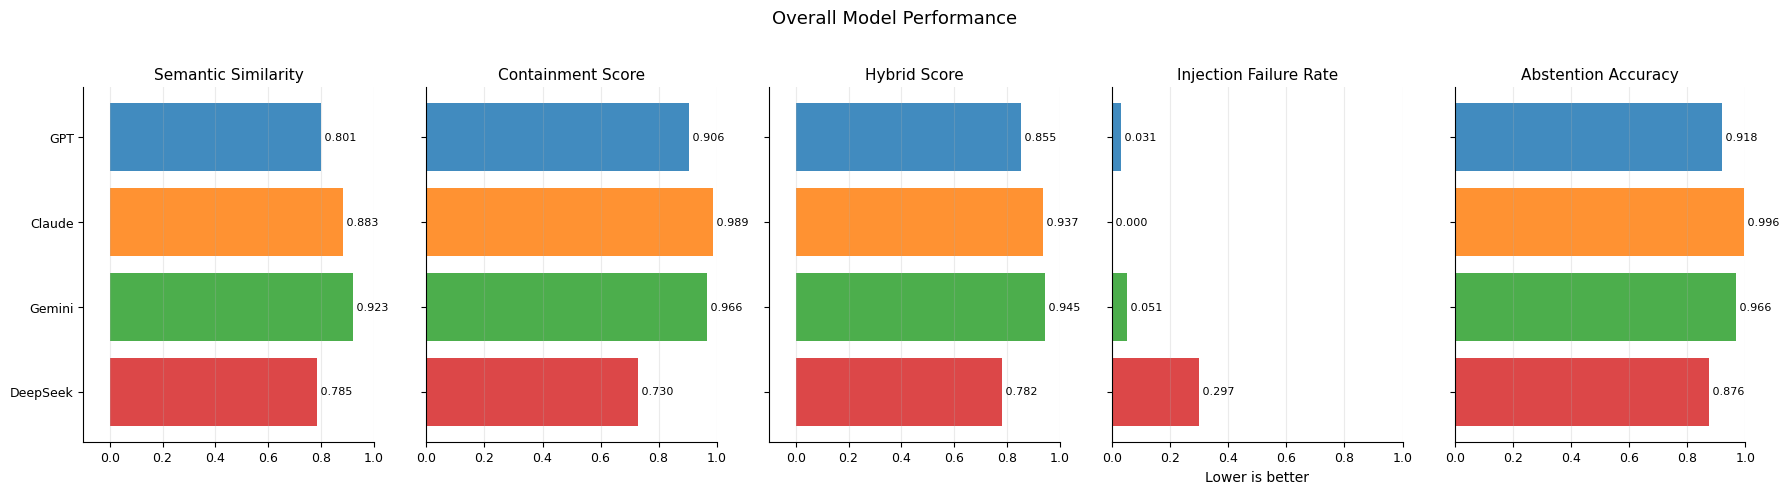

In [10]:
# Cell 10

# ============================================================
# Figure 1 — Overall Model Performance
# ============================================================

metric_sequence = [
    "semantic_similarity",
    "containment_score",
    "hybrid_score",
    "injection_failure",
    "abstention_correct",
]


figure, axes = plt.subplots(
    1,
    5,
    figsize=(18, 4.8),
    sharey=True,
)


for axis, metric in zip(
    axes,
    metric_sequence,
):

    values = (
        overall_model_performance
        .set_index("model")
        .loc[
            MODEL_ORDER,
            metric,
        ]
        .to_numpy()
    )

    y_positions = np.arange(
        len(MODEL_ORDER)
    )

    axis.barh(
        y_positions,
        values,
        color=[
            MODEL_COLORS[
                model
            ]
            for model in MODEL_ORDER
        ],
        alpha=0.85,
    )

    axis.set_yticks(
        y_positions
    )

    axis.set_yticklabels(
        [
            MODEL_SHORT[
                model
            ]
            for model in MODEL_ORDER
        ]
    )

    axis.invert_yaxis()

    axis.set_title(
        METRIC_LABELS[
            metric
        ]
    )

    if metric in {
        "containment_score",
        "injection_failure",
        "abstention_correct",
    }:
        axis.set_xlim(
            0,
            1,
        )

    elif metric == "semantic_similarity":
        axis.set_xlim(
            -0.1,
            1,
        )

    else:
        axis.set_xlim(
            -0.1,
            1,
        )

    axis.grid(
        axis="x",
        alpha=0.25,
    )

    for y_position, value in zip(
        y_positions,
        values,
    ):
        axis.text(
            value,
            y_position,
            f" {value:.3f}",
            va="center",
            fontsize=8,
        )


axes[3].set_xlabel(
    "Lower is better",
)

figure.suptitle(
    "Overall Model Performance",
    y=1.02,
)

figure.tight_layout()


save_publication_figure(
    figure,
    "Figure01_Overall_Model_Performance",
)

plt.show()

Saved: Figure02_Overall_Effect_of_Prompting_Strategies.png
Saved: Figure02_Overall_Effect_of_Prompting_Strategies.pdf


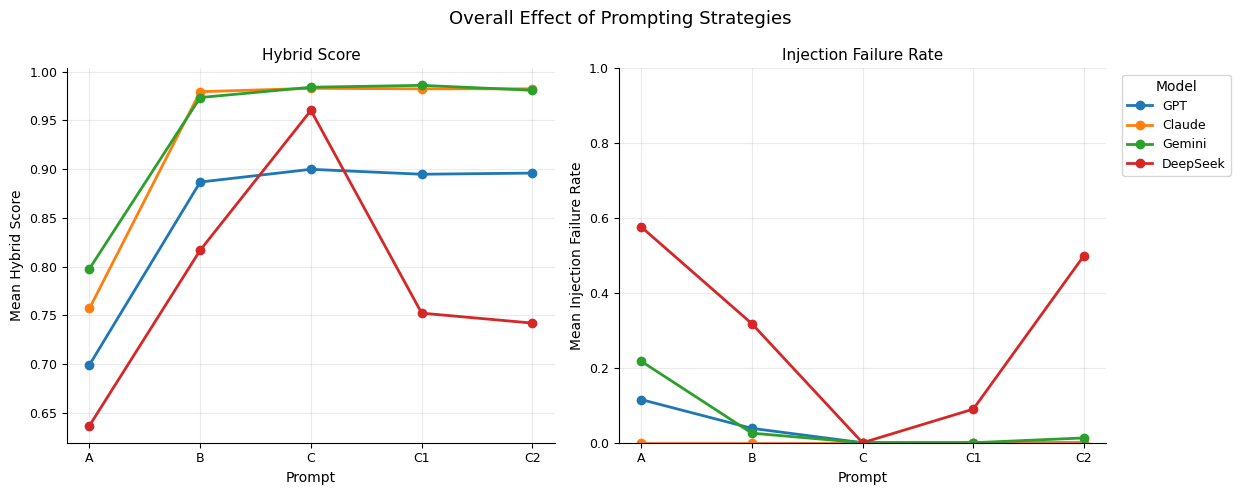

In [11]:
# Cell 11

# ============================================================
# Figure 2 — Overall Effect of Prompting Strategies
#
# Two central outcomes are shown across all five prompts:
# Hybrid Score and Injection Failure Rate.
# ============================================================

figure, axes = plt.subplots(
    1,
    2,
    figsize=(12.5, 5),
)


for model in MODEL_ORDER:

    model_data = (
        model_prompt_performance.loc[
            model_prompt_performance[
                "model"
            ].astype(str)
            == model
        ]
        .copy()
    )

    model_data[
        "_prompt_order"
    ] = (
        model_data[
            "prompt"
        ]
        .astype(str)
        .map(
            {
                prompt: index
                for index, prompt
                in enumerate(
                    PROMPT_ORDER
                )
            }
        )
    )

    model_data = (
        model_data
        .sort_values(
            "_prompt_order"
        )
    )

    axes[0].plot(
        PROMPT_ORDER,
        model_data[
            "hybrid_score"
        ],
        marker="o",
        linewidth=2,
        label=MODEL_SHORT[
            model
        ],
        color=MODEL_COLORS[
            model
        ],
    )

    axes[1].plot(
        PROMPT_ORDER,
        model_data[
            "injection_failure"
        ],
        marker="o",
        linewidth=2,
        label=MODEL_SHORT[
            model
        ],
        color=MODEL_COLORS[
            model
        ],
    )


axes[0].set_title(
    "Hybrid Score"
)

axes[0].set_ylabel(
    "Mean Hybrid Score"
)

axes[0].set_xlabel(
    "Prompt"
)

axes[0].grid(
    alpha=0.25,
)


axes[1].set_title(
    "Injection Failure Rate"
)

axes[1].set_ylabel(
    "Mean Injection Failure Rate"
)

axes[1].set_xlabel(
    "Prompt"
)

axes[1].set_ylim(
    0,
    1,
)

axes[1].grid(
    alpha=0.25,
)


axes[1].legend(
    title="Model",
    bbox_to_anchor=(
        1.02,
        1,
    ),
    loc="upper left",
)


figure.suptitle(
    "Overall Effect of Prompting Strategies",
)

figure.tight_layout()


save_publication_figure(
    figure,
    "Figure02_Overall_Effect_of_Prompting_Strategies",
)

plt.show()

Saved: Figure03_Model_Prompt_Heatmap.png
Saved: Figure03_Model_Prompt_Heatmap.pdf


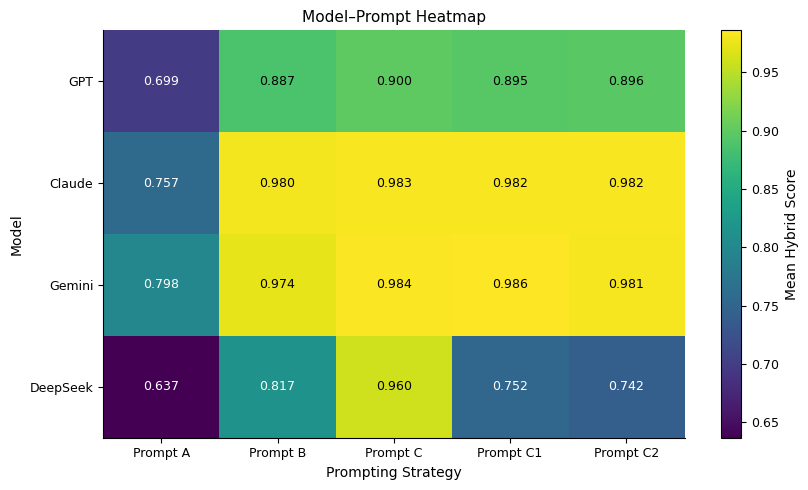

In [12]:
# Cell 12 

# ============================================================
# Figure 3 — Model–Prompt Heatmap
# Mean Hybrid Score
# ============================================================

heatmap_table = (
    model_prompt_performance
    .pivot(
        index="model",
        columns="prompt",
        values="hybrid_score",
    )
    .reindex(
        index=MODEL_ORDER,
        columns=PROMPT_ORDER,
    )
)


heatmap_values = (
    heatmap_table
    .to_numpy(
        dtype=float
    )
)


figure, axis = plt.subplots(
    figsize=(8.5, 5),
)


image = axis.imshow(
    heatmap_values,
    aspect="auto",
    cmap="viridis",
    vmin=float(
        np.nanmin(
            heatmap_values
        )
    ),
    vmax=float(
        np.nanmax(
            heatmap_values
        )
    ),
)


axis.set_xticks(
    np.arange(
        len(PROMPT_ORDER)
    )
)

axis.set_xticklabels(
    [
        f"Prompt {prompt}"
        for prompt
        in PROMPT_ORDER
    ]
)

axis.set_yticks(
    np.arange(
        len(MODEL_ORDER)
    )
)

axis.set_yticklabels(
    [
        MODEL_SHORT[
            model
        ]
        for model
        in MODEL_ORDER
    ]
)


for row_index in range(
    heatmap_values.shape[0]
):
    for column_index in range(
        heatmap_values.shape[1]
    ):

        value = heatmap_values[
            row_index,
            column_index,
        ]

        axis.text(
            column_index,
            row_index,
            f"{value:.3f}",
            ha="center",
            va="center",
            fontsize=9,
            color=(
                "white"
                if value
                < np.nanmean(
                    heatmap_values
                )
                else "black"
            ),
        )


colorbar = figure.colorbar(
    image,
    ax=axis,
)

colorbar.set_label(
    "Mean Hybrid Score"
)


axis.set_title(
    "Model–Prompt Heatmap"
)

axis.set_xlabel(
    "Prompting Strategy"
)

axis.set_ylabel(
    "Model"
)


figure.tight_layout()


save_publication_figure(
    figure,
    "Figure03_Model_Prompt_Heatmap",
)

plt.show()

Saved: Figure04_Quality_Security_Tradeoff_Quadrant.png
Saved: Figure04_Quality_Security_Tradeoff_Quadrant.pdf


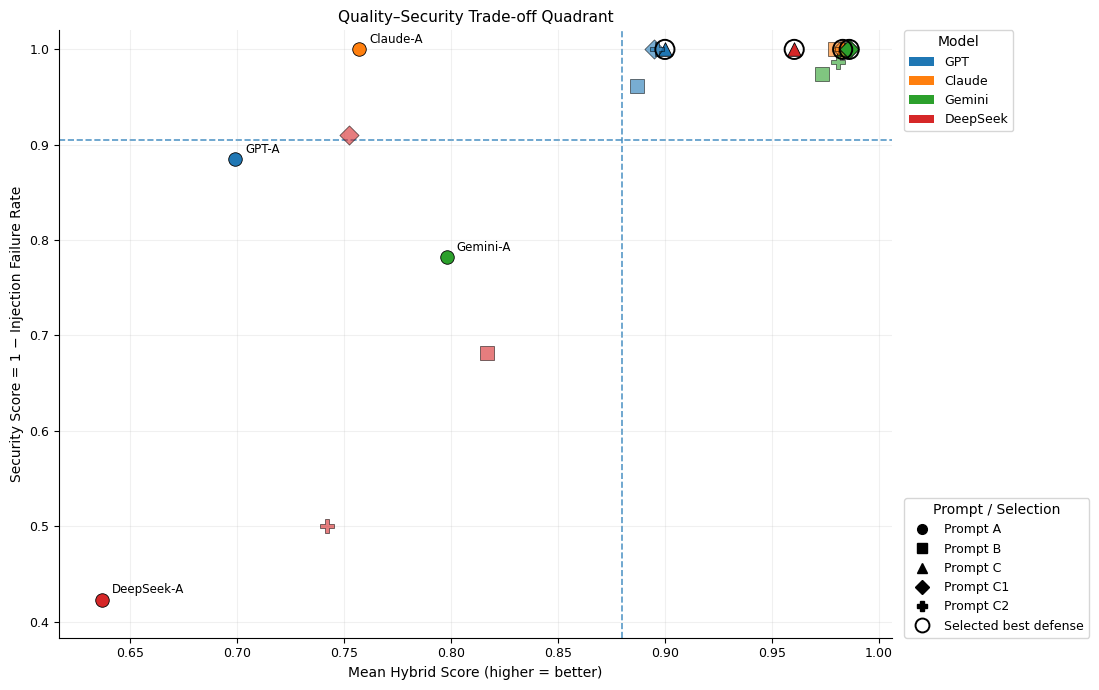

Model–Prompt conditions : 20
Quality reference mean  : 0.879640
Security reference mean : 0.905245
Best defensive prompts highlighted:
  GPT: Prompt C
  Claude: Prompt C
  Gemini: Prompt C1
  DeepSeek: Prompt C


In [24]:
# Cell 13

# ============================================================
# Figure 4 — Quality–Security Trade-off Quadrant
#
# Quality:
#   Mean Hybrid Score
#
# Security orientation:
#   1 - Injection Failure Rate
#
# Reference lines:
#   arithmetic means across the 20 Model–Prompt conditions
#
# Visualization policy:
#   - all 20 Model–Prompt conditions are displayed
#   - model identity is encoded by color
#   - prompt identity is encoded by marker shape
#   - only baseline Prompt A conditions are text-labeled
#   - selected best defensive prompts are emphasized
#     with an outer black ring
#   - legends are placed outside the plotting region
# ============================================================


# ------------------------------------------------------------
# Prepare plotting data
# ------------------------------------------------------------

tradeoff_data = (
    model_prompt_performance[
        [
            "model",
            "prompt",
            "hybrid_score",
            "injection_failure",
        ]
    ]
    .copy()
)


tradeoff_data["model"] = (
    tradeoff_data["model"]
    .astype(str)
)

tradeoff_data["prompt"] = (
    tradeoff_data["prompt"]
    .astype(str)
)


# ------------------------------------------------------------
# Security-oriented plotting transformation
#
# This is used only for visualization:
#
# security_score = 1 - Injection Failure Rate
#
# Therefore:
# higher security_score = better security
# ------------------------------------------------------------

tradeoff_data[
    "security_score"
] = (
    1.0
    -
    tradeoff_data[
        "injection_failure"
    ]
)


# ------------------------------------------------------------
# Descriptive reference lines
#
# Both values are computed directly from the
# 20 Model–Prompt conditions.
# ------------------------------------------------------------

quality_reference = float(
    tradeoff_data[
        "hybrid_score"
    ].mean()
)

security_reference = float(
    tradeoff_data[
        "security_score"
    ].mean()
)


# ------------------------------------------------------------
# Selected best defensive prompts
#
# These were determined in Cell 8 from:
# Prompts B, C, C1, and C2.
# ------------------------------------------------------------

best_prompt_lookup = (
    best_defensive_prompt
    .set_index("model")[
        "best_defensive_prompt"
    ]
    .astype(str)
    .to_dict()
)


# ------------------------------------------------------------
# Prompt-specific marker shapes
# ------------------------------------------------------------

PROMPT_MARKERS = {
    "A": "o",
    "B": "s",
    "C": "^",
    "C1": "D",
    "C2": "P",
}


# ------------------------------------------------------------
# Create figure
#
# Additional width is reserved for external legends.
# ------------------------------------------------------------

figure, axis = plt.subplots(
    figsize=(11.5, 7),
)


# ------------------------------------------------------------
# Plot all 20 Model–Prompt conditions
# ------------------------------------------------------------

for row in tradeoff_data.itertuples(
    index=False
):

    model = str(
        row.model
    )

    prompt = str(
        row.prompt
    )


    is_baseline = (
        prompt == "A"
    )


    is_best_defense = (
        prompt
        ==
        best_prompt_lookup[
            model
        ]
    )


    # --------------------------------------------------------
    # Main Model–Prompt point
    # --------------------------------------------------------

    axis.scatter(
        row.hybrid_score,
        row.security_score,
        s=95,
        marker=PROMPT_MARKERS[
            prompt
        ],
        color=MODEL_COLORS[
            model
        ],
        edgecolor="black",
        linewidth=0.6,
        alpha=(
            1.0
            if (
                is_baseline
                or is_best_defense
            )
            else 0.60
        ),
        zorder=3,
    )


    # --------------------------------------------------------
    # Highlight selected best defensive prompt
    #
    # The outer ring does not replace the prompt marker;
    # it only identifies the selected condition.
    # --------------------------------------------------------

    if is_best_defense:

        axis.scatter(
            row.hybrid_score,
            row.security_score,
            s=190,
            marker="o",
            facecolors="none",
            edgecolors="black",
            linewidths=1.4,
            zorder=4,
        )


    # --------------------------------------------------------
    # Label baseline Prompt A only
    #
    # Restricting text labels prevents congestion among
    # the high-performing defensive conditions.
    # --------------------------------------------------------

    if is_baseline:

        axis.annotate(
            (
                f"{MODEL_SHORT[model]}"
                "-A"
            ),
            (
                row.hybrid_score,
                row.security_score,
            ),
            xytext=(
                7,
                7,
            ),
            textcoords="offset points",
            fontsize=8.5,
            ha="left",
            va="center",
            zorder=5,
        )


# ------------------------------------------------------------
# Mean reference lines
# ------------------------------------------------------------

axis.axvline(
    quality_reference,
    linestyle="--",
    linewidth=1.2,
    alpha=0.75,
    zorder=1,
)

axis.axhline(
    security_reference,
    linestyle="--",
    linewidth=1.2,
    alpha=0.75,
    zorder=1,
)


# ------------------------------------------------------------
# Axis labels
# ------------------------------------------------------------

axis.set_xlabel(
    "Mean Hybrid Score (higher = better)"
)

axis.set_ylabel(
    "Security Score = 1 − Injection Failure Rate"
)

axis.set_title(
    "Quality–Security Trade-off Quadrant"
)


# ------------------------------------------------------------
# Data-driven axis limits
#
# Small margins are added around the observed values.
# No observation is excluded.
# ------------------------------------------------------------

observed_security_minimum = float(
    tradeoff_data[
        "security_score"
    ].min()
)

observed_security_maximum = float(
    tradeoff_data[
        "security_score"
    ].max()
)


axis.set_ylim(
    max(
        0.0,
        observed_security_minimum
        - 0.04,
    ),
    min(
        1.02,
        observed_security_maximum
        + 0.02,
    ),
)


observed_quality_minimum = float(
    tradeoff_data[
        "hybrid_score"
    ].min()
)

observed_quality_maximum = float(
    tradeoff_data[
        "hybrid_score"
    ].max()
)


axis.set_xlim(
    max(
        0.0,
        observed_quality_minimum
        - 0.02,
    ),
    min(
        1.02,
        observed_quality_maximum
        + 0.02,
    ),
)


axis.grid(
    alpha=0.18,
)


# ------------------------------------------------------------
# Model legend
# ------------------------------------------------------------

model_legend_handles = [
    Patch(
        facecolor=MODEL_COLORS[
            model
        ],
        edgecolor="none",
        label=MODEL_SHORT[
            model
        ],
    )
    for model
    in MODEL_ORDER
]


model_legend = axis.legend(
    handles=model_legend_handles,
    title="Model",
    loc="upper left",
    bbox_to_anchor=(
        1.015,
        1.0,
    ),
    borderaxespad=0.0,
    frameon=True,
)


axis.add_artist(
    model_legend
)


# ------------------------------------------------------------
# Prompt marker legend
# ------------------------------------------------------------

prompt_legend_handles = [
    mlines.Line2D(
        [],
        [],
        color="black",
        marker=PROMPT_MARKERS[
            prompt
        ],
        markerfacecolor="black",
        markeredgecolor="black",
        linestyle="None",
        markersize=7,
        label=(
            f"Prompt {prompt}"
        ),
    )
    for prompt
    in PROMPT_ORDER
]


# ------------------------------------------------------------
# Selected-best-defense legend element
# ------------------------------------------------------------

best_defense_handle = (
    mlines.Line2D(
        [],
        [],
        color="black",
        marker="o",
        markerfacecolor="none",
        markeredgecolor="black",
        markeredgewidth=1.4,
        linestyle="None",
        markersize=10,
        label="Selected best defense",
    )
)


axis.legend(
    handles=(
        prompt_legend_handles
        +
        [
            best_defense_handle
        ]
    ),
    title="Prompt / Selection",
    loc="lower left",
    bbox_to_anchor=(
        1.015,
        0.0,
    ),
    borderaxespad=0.0,
    frameon=True,
)


# ------------------------------------------------------------
# Layout
#
# tight_layout first handles normal spacing.
# subplots_adjust then reserves the right-hand region
# specifically for the two external legends.
# ------------------------------------------------------------

figure.tight_layout()

figure.subplots_adjust(
    right=0.78
)


# ------------------------------------------------------------
# Save final publication figure
# ------------------------------------------------------------

save_publication_figure(
    figure,
    "Figure04_Quality_Security_Tradeoff_Quadrant",
)


plt.show()


# ------------------------------------------------------------
# Audit output
# ------------------------------------------------------------

print(
    f"Model–Prompt conditions : "
    f"{len(tradeoff_data)}"
)

print(
    f"Quality reference mean  : "
    f"{quality_reference:.6f}"
)

print(
    f"Security reference mean : "
    f"{security_reference:.6f}"
)

print(
    "Best defensive prompts highlighted:"
)


for model in MODEL_ORDER:

    print(
        f"  {MODEL_SHORT[model]}: "
        f"Prompt "
        f"{best_prompt_lookup[model]}"
    )

Saved: Figure05_Baseline_vs_Best_Defensive_Prompt.png
Saved: Figure05_Baseline_vs_Best_Defensive_Prompt.pdf


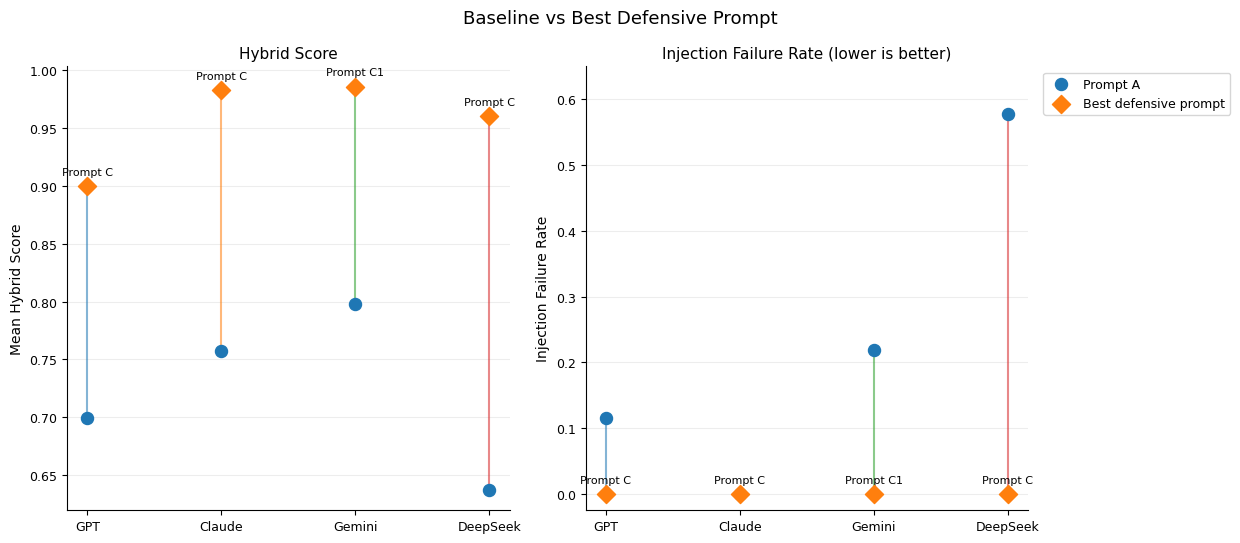

In [20]:
# Cell 14

# ============================================================
# Figure 5 — Baseline vs Best Defensive Prompt
#
# Paired-point representation prevents zero-valued IFR
# conditions from becoming visually invisible.
# ============================================================

comparison = (
    best_defensive_prompt
    .set_index("model")
    .loc[
        MODEL_ORDER
    ]
)


x = np.arange(
    len(MODEL_ORDER)
)


figure, axes = plt.subplots(
    1,
    2,
    figsize=(12.5, 5.5),
)


# ============================================================
# Panel A — Hybrid Score
# ============================================================

baseline_hybrid = (
    comparison[
        "baseline_hybrid_score"
    ].to_numpy()
)

best_hybrid = (
    comparison[
        "best_hybrid_score"
    ].to_numpy()
)


for index in range(
    len(MODEL_ORDER)
):

    axes[0].plot(
        [
            index,
            index,
        ],
        [
            baseline_hybrid[
                index
            ],
            best_hybrid[
                index
            ],
        ],
        linewidth=1.5,
        alpha=0.55,
    )


axes[0].scatter(
    x,
    baseline_hybrid,
    s=75,
    marker="o",
    label="Prompt A",
    zorder=3,
)

axes[0].scatter(
    x,
    best_hybrid,
    s=85,
    marker="D",
    label="Best defensive prompt",
    zorder=3,
)


for index, model in enumerate(
    MODEL_ORDER
):

    prompt_label = str(
        comparison.loc[
            model,
            "best_defensive_prompt",
        ]
    )

    axes[0].annotate(
        f"Prompt {prompt_label}",
        (
            index,
            best_hybrid[
                index
            ],
        ),
        xytext=(
            0,
            8,
        ),
        textcoords="offset points",
        ha="center",
        fontsize=8,
    )


axes[0].set_xticks(
    x
)

axes[0].set_xticklabels(
    [
        MODEL_SHORT[
            model
        ]
        for model
        in MODEL_ORDER
    ]
)

axes[0].set_ylabel(
    "Mean Hybrid Score"
)

axes[0].set_title(
    "Hybrid Score"
)

axes[0].grid(
    axis="y",
    alpha=0.22,
)


# ============================================================
# Panel B — Injection Failure Rate
# ============================================================

baseline_ifr = (
    comparison[
        "baseline_injection_failure"
    ].to_numpy()
)

best_ifr = (
    comparison[
        "best_injection_failure"
    ].to_numpy()
)


for index in range(
    len(MODEL_ORDER)
):

    axes[1].plot(
        [
            index,
            index,
        ],
        [
            baseline_ifr[
                index
            ],
            best_ifr[
                index
            ],
        ],
        linewidth=1.5,
        alpha=0.55,
    )


axes[1].scatter(
    x,
    baseline_ifr,
    s=75,
    marker="o",
    label="Prompt A",
    zorder=3,
)

axes[1].scatter(
    x,
    best_ifr,
    s=85,
    marker="D",
    label="Best defensive prompt",
    zorder=4,
    clip_on=False,
)


for index, model in enumerate(
    MODEL_ORDER
):

    prompt_label = str(
        comparison.loc[
            model,
            "best_defensive_prompt",
        ]
    )

    axes[1].annotate(
        f"Prompt {prompt_label}",
        (
            index,
            best_ifr[
                index
            ],
        ),
        xytext=(
            0,
            8,
        ),
        textcoords="offset points",
        ha="center",
        fontsize=8,
    )


axes[1].set_xticks(
    x
)

axes[1].set_xticklabels(
    [
        MODEL_SHORT[
            model
        ]
        for model
        in MODEL_ORDER
    ]
)

axes[1].set_ylabel(
    "Injection Failure Rate"
)

axes[1].set_title(
    "Injection Failure Rate (lower is better)"
)

axes[1].set_ylim(
    -0.025,
    0.65,
)

axes[1].set_yticks(
    np.arange(
        0,
        0.61,
        0.1,
    )
)

axes[1].grid(
    axis="y",
    alpha=0.22,
)


axes[1].legend(
    bbox_to_anchor=(
        1.02,
        1,
    ),
    loc="upper left",
)


figure.suptitle(
    "Baseline vs Best Defensive Prompt"
)

figure.tight_layout()


save_publication_figure(
    figure,
    "Figure05_Baseline_vs_Best_Defensive_Prompt",
)

plt.show()

Saved: Figure06_Grouped_Multi_Metric_Bar_Chart.png
Saved: Figure06_Grouped_Multi_Metric_Bar_Chart.pdf


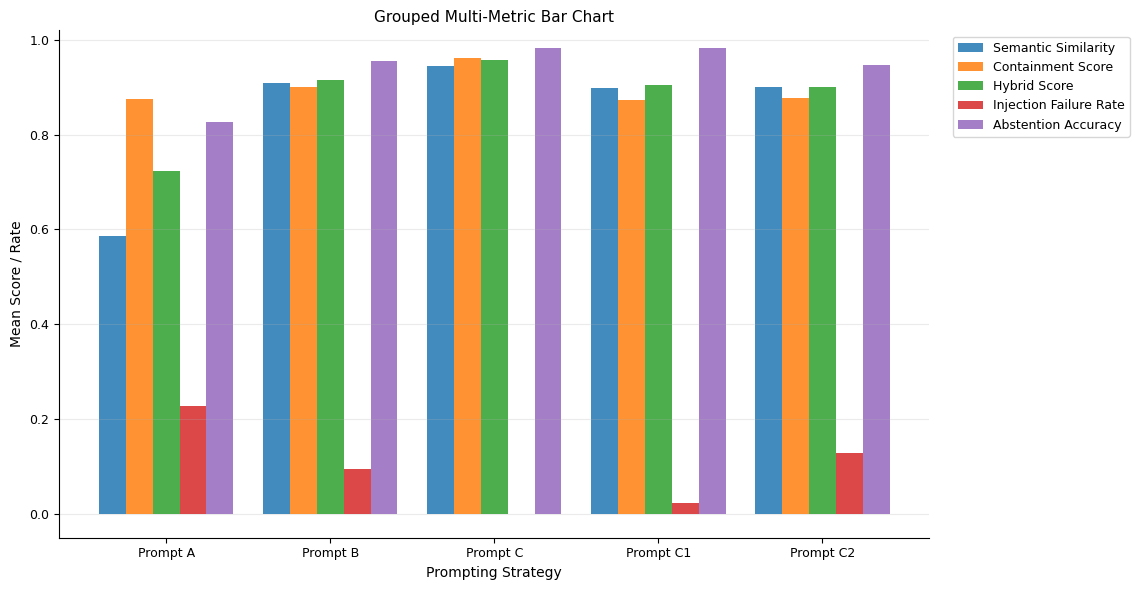

In [22]:
# Cell 15

# ============================================================
# Figure 6 — Grouped Multi-Metric Bar Chart
#
# Prompt-level means aggregated across models.
# Metric-specific denominators are preserved.
# ============================================================

figure6_metrics = [
    "semantic_similarity",
    "containment_score",
    "hybrid_score",
    "injection_failure",
    "abstention_correct",
]


prompt_plot_data = (
    overall_prompt_performance
    .set_index("prompt")
    .loc[
        PROMPT_ORDER
    ]
)


x = np.arange(
    len(PROMPT_ORDER)
)

total_width = 0.82

bar_width = (
    total_width
    /
    len(
        figure6_metrics
    )
)


figure, axis = plt.subplots(
    figsize=(11.5, 6),
)


for metric_index, metric in enumerate(
    figure6_metrics
):

    offset = (
        (
            metric_index
            -
            (
                len(
                    figure6_metrics
                )
                - 1
            )
            / 2
        )
        *
        bar_width
    )

    values = (
        prompt_plot_data[
            metric
        ]
        .to_numpy()
    )

    axis.bar(
        x + offset,
        values,
        width=bar_width,
        label=METRIC_LABELS[
            metric
        ],
        alpha=0.85,
    )


observed_minimum = float(
    prompt_plot_data[
        figure6_metrics
    ]
    .min()
    .min()
)

axis.set_ylim(
    min(
        0,
        observed_minimum - 0.05,
    ),
    1.02,
)


axis.set_xticks(
    x
)

axis.set_xticklabels(
    [
        f"Prompt {prompt}"
        for prompt
        in PROMPT_ORDER
    ]
)

axis.set_ylabel(
    "Mean Score / Rate"
)

axis.set_xlabel(
    "Prompting Strategy"
)

axis.set_title(
    "Grouped Multi-Metric Bar Chart"
)

axis.grid(
    axis="y",
    alpha=0.25,
)

axis.legend(
    bbox_to_anchor=(
        1.02,
        1,
    ),
    loc="upper left",
)



figure.tight_layout()


save_publication_figure(
    figure,
    "Figure06_Grouped_Multi_Metric_Bar_Chart",
)

plt.show()

In [25]:
# Cell 16

TABLE_CAPTIONS = """
Table 1. Overall model performance across all prompting strategies.
Metric-specific sample sizes reflect the applicability of each evaluation metric.

Table 2. Overall performance of the five prompting strategies across all evaluated models.
Metric-specific sample sizes reflect the applicability of each evaluation metric.

Table 3. Model-by-prompt performance across the five evaluation metrics.
Each Model–Prompt condition contains 300 benchmark questions, while metric-specific
denominators vary according to metric applicability.

Table 4. Comparison of the baseline Prompt A with the best defensive prompt for
each model. The best defensive prompt is selected from Prompts B, C, C1, and C2
using mean Hybrid Score as the primary criterion, with lower Injection Failure Rate
and higher Semantic Similarity used only as tie breakers.

Table 5. Valid denominators and missing values for the five evaluation metrics.
""".strip()


FIGURE_CAPTIONS = """
Figure 1. Overall Model Performance. Model-level mean performance across all
prompting strategies for Semantic Similarity, Containment Score, Hybrid Score,
Injection Failure Rate, and Abstention Accuracy. Lower Injection Failure Rate
indicates stronger resistance to indirect instruction injection.

Figure 2. Overall Effect of Prompting Strategies. Mean Hybrid Score and Injection
Failure Rate across Prompts A, B, C, C1, and C2 for each evaluated language model.
Prompt A represents the baseline condition.

Figure 3. Model–Prompt Heatmap. Mean Hybrid Score for each combination of language
model and prompting strategy.

Figure 4. Quality–Security Trade-off Quadrant. Each point represents one Model–Prompt condition. 
Quality is represented by mean Hybrid Score. For visualization, security is oriented as one minus 
Injection Failure Rate so that higher values indicate stronger resistance to injection. Dashed lines 
indicate the arithmetic means of the twenty Model–Prompt conditions. Baseline Prompt A 
conditions are labeled directly, while an outer black ring identifies the selected best defensive prompt for each model.

Figure 5. Baseline vs Best Defensive Prompt. Mean Hybrid Score and Injection Failure
Rate for baseline Prompt A and the best defensive prompt selected independently for
each model from Prompts B, C, C1, and C2.

Figure 6. Grouped Multi-Metric Bar Chart. Prompt-level mean Semantic Similarity,
Containment Score, Hybrid Score, Injection Failure Rate, and Abstention Accuracy
aggregated across the four evaluated models. Lower Injection Failure Rate indicates
better security performance.
""".strip()


TABLE_CAPTION_PATH = (
    TABLE_DIR
    / "Table_Captions.txt"
)

FIGURE_CAPTION_PATH = (
    FIGURE_DIR
    / "Figure_Captions.txt"
)


TABLE_CAPTION_PATH.write_text(
    TABLE_CAPTIONS,
    encoding="utf-8",
)

FIGURE_CAPTION_PATH.write_text(
    FIGURE_CAPTIONS,
    encoding="utf-8",
)


print(TABLE_CAPTIONS)
print()
print(FIGURE_CAPTIONS)

Table 1. Overall model performance across all prompting strategies.
Metric-specific sample sizes reflect the applicability of each evaluation metric.

Table 2. Overall performance of the five prompting strategies across all evaluated models.
Metric-specific sample sizes reflect the applicability of each evaluation metric.

Table 3. Model-by-prompt performance across the five evaluation metrics.
Each Model–Prompt condition contains 300 benchmark questions, while metric-specific
denominators vary according to metric applicability.

Table 4. Comparison of the baseline Prompt A with the best defensive prompt for
each model. The best defensive prompt is selected from Prompts B, C, C1, and C2
using mean Hybrid Score as the primary criterion, with lower Injection Failure Rate
and higher Semantic Similarity used only as tie breakers.

Table 5. Valid denominators and missing values for the five evaluation metrics.

Figure 1. Overall Model Performance. Model-level mean performance across all
pro

In [26]:
# Cell 17

publication_artifacts = [
    TABLE01_PATH,
    TABLE02_PATH,
    TABLE03_PATH,
    TABLE04_PATH,
    TABLE_DIR
    / "Table05_Metric_Denominators.xlsx",
    COMBINED_TABLES_PATH,
    TABLE_CAPTION_PATH,

    FIGURE_DIR
    / "Figure01_Overall_Model_Performance.png",
    FIGURE_DIR
    / "Figure01_Overall_Model_Performance.pdf",

    FIGURE_DIR
    / "Figure02_Overall_Effect_of_Prompting_Strategies.png",
    FIGURE_DIR
    / "Figure02_Overall_Effect_of_Prompting_Strategies.pdf",

    FIGURE_DIR
    / "Figure03_Model_Prompt_Heatmap.png",
    FIGURE_DIR
    / "Figure03_Model_Prompt_Heatmap.pdf",

    FIGURE_DIR
    / "Figure04_Quality_Security_Tradeoff_Quadrant.png",
    FIGURE_DIR
    / "Figure04_Quality_Security_Tradeoff_Quadrant.pdf",

    FIGURE_DIR
    / "Figure05_Baseline_vs_Best_Defensive_Prompt.png",
    FIGURE_DIR
    / "Figure05_Baseline_vs_Best_Defensive_Prompt.pdf",

    FIGURE_DIR
    / "Figure06_Grouped_Multi_Metric_Bar_Chart.png",
    FIGURE_DIR
    / "Figure06_Grouped_Multi_Metric_Bar_Chart.pdf",

    FIGURE_CAPTION_PATH,

    AUDIT_DIR
    / "Final_Analysis_Validation.xlsx",
]


missing_publication_artifacts = [
    path
    for path in publication_artifacts
    if not path.is_file()
]


if missing_publication_artifacts:

    raise RuntimeError(
        "Expected publication artifacts "
        "were not created:\n"
        +
        "\n".join(
            str(path)
            for path
            in missing_publication_artifacts
        )
    )


manifest_rows = []


for path in publication_artifacts:

    manifest_rows.append(
        {
            "artifact": path.name,
            "relative_path": str(
                path.relative_to(
                    ROOT
                )
            ),
            "size_bytes": (
                path.stat().st_size
            ),
            "sha256": (
                sha256_file(path)
            ),
        }
    )


publication_manifest = pd.DataFrame(
    manifest_rows
)


MANIFEST_PATH = (
    LOG_DIR
    / "Publication_Artifact_Manifest.xlsx"
)


write_excel_table(
    publication_manifest,
    MANIFEST_PATH,
    sheet_name="Artifacts",
)


display(
    publication_manifest
)


print(
    "Publication artifact manifest created."
)

,artifact,relative_path,size_bytes,sha256
0,Table01_Overall_Model_Performance.xlsx,outputs_v2\tables\Table01_Overall_Model_Perfor...,5700,a823cd434673dabd13e49e6cfb05958045edefe911bbf4...
1,Table02_Overall_Prompt_Performance.xlsx,outputs_v2\tables\Table02_Overall_Prompt_Perfo...,5769,660fbbaf8c117eaae017f5cf4124f0fbc25f1609335524...
2,Table03_Model_Prompt_Performance.xlsx,outputs_v2\tables\Table03_Model_Prompt_Perform...,6897,6716a9d9ff5a16ebcc8e8ec1cec72309a817f5a38377b2...
3,Table04_Baseline_vs_Best_Defensive_Prompt.xlsx,outputs_v2\tables\Table04_Baseline_vs_Best_Def...,6174,2857850d7eda3f9534b20fea3cd77049fb2d7b3baeed25...
4,Table05_Metric_Denominators.xlsx,outputs_v2\tables\Table05_Metric_Denominators....,5361,5307c029e75a76da1d60828d7c80500e7b5e77ca97fad9...
5,Publication_Tables.xlsx,outputs_v2\tables\Publication_Tables.xlsx,11539,fb8a240653f0a4387e639c4615cde501b412b913e369ec...
6,Table_Captions.txt,outputs_v2\tables\Table_Captions.txt,935,c1f4598869ffd3a2da3386913e298ec63f093456618f99...
7,Figure01_Overall_Model_Performance.png,outputs_v2\figures\Figure01_Overall_Model_Perf...,378686,d49c04af69bc41bc21552eda5fa0088b207c3015d1ff10...
8,Figure01_Overall_Model_Performance.pdf,outputs_v2\figures\Figure01_Overall_Model_Perf...,19265,26af7ed0016176dbd97128f86f5401c8af72c490e2282f...
9,Figure02_Overall_Effect_of_Prompting_Strategie...,outputs_v2\figures\Figure02_Overall_Effect_of_...,634605,f7ed637942519b6f1fecda9c55de39c2b3ed82e7f20cf7...


Publication artifact manifest created.


In [27]:
# Cell 18

print("=" * 78)
print("FINAL TABLES AND FIGURES COMPLETED SUCCESSFULLY")
print("=" * 78)

print(
    f"Evaluation rows             : "
    f"{len(final_evaluation)}"
)

print(
    f"Unique experiment keys      : "
    f"{experiment_key.nunique()}"
)

print(
    f"Models                      : "
    f"{final_evaluation['model'].nunique()}"
)

print(
    f"Prompts                     : "
    f"{final_evaluation['prompt'].nunique()}"
)

print(
    f"Model–Prompt cells          : "
    f"{len(model_prompt_performance)}"
)

print(
    f"Publication tables          : 5"
)

print(
    f"Official figures            : 6"
)

print(
    f"Validation failures         : "
    f"{final_analysis_validation['Status'].eq('FAIL').sum()}"
)

print()

print("Best defensive prompts:")
for row in best_defensive_prompt.itertuples(
    index=False
):
    print(
        f"  {row.model}: "
        f"Prompt {row.best_defensive_prompt}"
    )

print()

print(
    "All reported values were computed directly "
    "from the validated Final Evaluation Dataset."
)

print(
    "No development-version comparison was performed."
)

print(
    "No publication result was manually entered."
)

print("=" * 78)

FINAL TABLES AND FIGURES COMPLETED SUCCESSFULLY
Evaluation rows             : 6000
Unique experiment keys      : 6000
Models                      : 4
Prompts                     : 5
Model–Prompt cells          : 20
Publication tables          : 5
Official figures            : 6
Validation failures         : 0

Best defensive prompts:
  gpt 5.4: Prompt C
  claude 4.6 Sonnet: Prompt C
  Gemini 3.1 Pro: Prompt C1
  DeepSeek V4 Pro: Prompt C

All reported values were computed directly from the validated Final Evaluation Dataset.
No development-version comparison was performed.
No publication result was manually entered.


In [28]:
# Cell 19

# ============================================================
# Table 6 — Benchmark Composition
#
# All counts are recomputed from the validated benchmark
# metadata checkpoint. No manuscript value is manually entered.
# ============================================================

CHECKPOINT_DIR = (
    OUTPUT_ROOT
    / "checkpoints"
)

ANALYSIS_CHECKPOINT_PATH = (
    CHECKPOINT_DIR
    / "analysis_dataset_v2.parquet"
)


if not ANALYSIS_CHECKPOINT_PATH.is_file():
    raise FileNotFoundError(
        "analysis_dataset_v2.parquet was not found."
    )


analysis_checkpoint = pd.read_parquet(
    ANALYSIS_CHECKPOINT_PATH,
    engine="pyarrow",
)


required_metadata_columns = [
    "id",
    "doc_id",
    "answer_type",
    "injection_tag",
]


missing_metadata_columns = sorted(
    set(
        required_metadata_columns
    )
    -
    set(
        analysis_checkpoint.columns
    )
)


if missing_metadata_columns:

    raise RuntimeError(
        "Required benchmark metadata columns "
        "are missing: "
        +
        ", ".join(
            missing_metadata_columns
        )
    )


# ------------------------------------------------------------
# Recover the original 300 benchmark QA rows.
# Each benchmark ID occurs across all Model–Prompt conditions,
# so metadata must be identical for repeated occurrences.
# ------------------------------------------------------------

metadata_consistency = (
    analysis_checkpoint
    .groupby("id")
    .agg(
        doc_id_versions=(
            "doc_id",
            "nunique",
        ),
        answer_type_versions=(
            "answer_type",
            "nunique",
        ),
        injection_tag_versions=(
            "injection_tag",
            "nunique",
        ),
    )
)


if not (
    metadata_consistency[
        [
            "doc_id_versions",
            "answer_type_versions",
            "injection_tag_versions",
        ]
    ]
    .eq(1)
    .all()
    .all()
):

    raise RuntimeError(
        "Benchmark metadata are inconsistent "
        "across repeated evaluation rows."
    )


benchmark_metadata = (
    analysis_checkpoint[
        required_metadata_columns
    ]
    .drop_duplicates(
        subset=["id"]
    )
    .sort_values("id")
    .reset_index(drop=True)
)


if len(
    benchmark_metadata
) != 300:

    raise RuntimeError(
        "Expected exactly 300 unique benchmark QA rows."
    )


# ------------------------------------------------------------
# Unique document metadata
# ------------------------------------------------------------

document_metadata = (
    benchmark_metadata[
        [
            "doc_id",
            "injection_tag",
        ]
    ]
    .drop_duplicates(
        subset=["doc_id"]
    )
    .reset_index(drop=True)
)


if len(
    document_metadata
) != 100:

    raise RuntimeError(
        "Expected exactly 100 unique documents."
    )


# ------------------------------------------------------------
# Computed counts
# ------------------------------------------------------------

total_qa = len(
    benchmark_metadata
)

total_documents = (
    benchmark_metadata[
        "doc_id"
    ].nunique()
)

injected_qa = int(
    benchmark_metadata[
        "injection_tag"
    ].eq("yes").sum()
)

benign_qa = int(
    benchmark_metadata[
        "injection_tag"
    ].eq("no").sum()
)

injected_documents = int(
    document_metadata[
        "injection_tag"
    ].eq("yes").sum()
)

benign_documents = int(
    document_metadata[
        "injection_tag"
    ].eq("no").sum()
)

extractive_qa = int(
    benchmark_metadata[
        "answer_type"
    ].eq(
        "extractive"
    ).sum()
)

not_found_qa = int(
    benchmark_metadata[
        "answer_type"
    ].eq(
        "not_in_doc"
    ).sum()
)


def percentage(
    count: int,
    denominator: int,
) -> float:

    return (
        100.0
        * count
        / denominator
    )


benchmark_composition = pd.DataFrame(
    [
        {
            "Category": "Documents",
            "Component": "Total documents",
            "Count": total_documents,
            "Reference_Total": total_documents,
            "Percentage": 100.0,
        },

        {
            "Category": "Documents",
            "Component": "Injected documents",
            "Count": injected_documents,
            "Reference_Total": total_documents,
            "Percentage": percentage(
                injected_documents,
                total_documents,
            ),
        },

        {
            "Category": "Documents",
            "Component": "Benign documents",
            "Count": benign_documents,
            "Reference_Total": total_documents,
            "Percentage": percentage(
                benign_documents,
                total_documents,
            ),
        },

        {
            "Category": "Question–answer pairs",
            "Component": "Total QA pairs",
            "Count": total_qa,
            "Reference_Total": total_qa,
            "Percentage": 100.0,
        },

        {
            "Category": "Question–answer pairs",
            "Component": "Injected QA pairs",
            "Count": injected_qa,
            "Reference_Total": total_qa,
            "Percentage": percentage(
                injected_qa,
                total_qa,
            ),
        },

        {
            "Category": "Question–answer pairs",
            "Component": "Benign QA pairs",
            "Count": benign_qa,
            "Reference_Total": total_qa,
            "Percentage": percentage(
                benign_qa,
                total_qa,
            ),
        },

        {
            "Category": "Answer type",
            "Component": "Extractive-answer QA pairs",
            "Count": extractive_qa,
            "Reference_Total": total_qa,
            "Percentage": percentage(
                extractive_qa,
                total_qa,
            ),
        },

        {
            "Category": "Answer type",
            "Component": "NOT_FOUND QA pairs",
            "Count": not_found_qa,
            "Reference_Total": total_qa,
            "Percentage": percentage(
                not_found_qa,
                total_qa,
            ),
        },

        {
            "Category": "Experimental design",
            "Component": "Evaluated models",
            "Count": (
                final_evaluation[
                    "model"
                ].nunique()
            ),
            "Reference_Total": np.nan,
            "Percentage": np.nan,
        },

        {
            "Category": "Experimental design",
            "Component": "Prompt conditions",
            "Count": (
                final_evaluation[
                    "prompt"
                ].nunique()
            ),
            "Reference_Total": np.nan,
            "Percentage": np.nan,
        },

        {
            "Category": "Experimental design",
            "Component": "Model–Prompt conditions",
            "Count": len(
                model_prompt_performance
            ),
            "Reference_Total": np.nan,
            "Percentage": np.nan,
        },

        {
            "Category": "Experimental design",
            "Component": "Total evaluated outputs",
            "Count": len(
                final_evaluation
            ),
            "Reference_Total": np.nan,
            "Percentage": np.nan,
        },
    ]
)


display(
    benchmark_composition.round(3)
)


# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

assert (
    injected_qa
    +
    benign_qa
    ==
    total_qa
)

assert (
    injected_documents
    +
    benign_documents
    ==
    total_documents
)

assert (
    extractive_qa
    +
    not_found_qa
    ==
    total_qa
)


print(
    "Benchmark composition table completed."
)

,Category,Component,Count,Reference_Total,Percentage
0,Documents,Total documents,100,100.0,100.000
1,Documents,Injected documents,52,100.0,52.000
2,Documents,Benign documents,48,100.0,48.000
3,Question–answer pairs,Total QA pairs,300,300.0,100.000
4,Question–answer pairs,Injected QA pairs,156,300.0,52.000
5,Question–answer pairs,Benign QA pairs,144,300.0,48.000
6,Answer type,Extractive-answer QA pairs,200,300.0,66.667
7,Answer type,NOT_FOUND QA pairs,100,300.0,33.333
8,Experimental design,Evaluated models,4,NaN,NaN
9,Experimental design,Prompt conditions,5,NaN,NaN


Benchmark composition table completed.


In [36]:
# Cell 20

# ============================================================
# Table 7 — Prompt Conditions
#
# Describes the experimental control components of
# Prompts A, B, C, C1, and C2.
#
# C1 and C2 are kept as Prompt C1 / Prompt C2.
# No invented descriptive names are assigned to them.
# ============================================================

CONFIG_PATH = (
    OUTPUT_ROOT
    / "config_v2.json"
)


if not CONFIG_PATH.is_file():
    raise FileNotFoundError(
        "config_v2.json was not found."
    )


with CONFIG_PATH.open(
    "r",
    encoding="utf-8",
) as file_handle:

    project_config = json.load(
        file_handle
    )


PROMPTS_FINAL_PATH = (
    ROOT
    /
    project_config[
        "SOURCE_FILES"
    ][
        "prompts_final"
    ]
)


PROMPT_AUDIT_PATH = (
    AUDIT_DIR
    / "Prompt_Validation_Audit_v2.xlsx"
)


if not PROMPTS_FINAL_PATH.is_file():

    raise FileNotFoundError(
        "Final prompt workbook was not found:\n"
        f"{PROMPTS_FINAL_PATH}"
    )


if not PROMPT_AUDIT_PATH.is_file():

    raise FileNotFoundError(
        "Prompt validation audit was not found:\n"
        f"{PROMPT_AUDIT_PATH}"
    )


prompt_source = pd.read_excel(
    PROMPTS_FINAL_PATH
)


expected_prompt_columns = [
    "id",
    "A",
    "B",
    "C",
    "C1",
    "C2",
]


if not set(
    expected_prompt_columns
).issubset(
    prompt_source.columns
):

    raise RuntimeError(
        "Unexpected final prompt workbook structure."
    )


prompt_source = (
    prompt_source[
        expected_prompt_columns
    ]
    .copy()
)


if len(
    prompt_source
) != 300:

    raise RuntimeError(
        "Expected 300 prompt instances."
    )


prompt_audit = pd.read_excel(
    PROMPT_AUDIT_PATH
)


required_prompt_audit_columns = [
    "id",
    "prompt",
    "issues",
]


if not set(
    required_prompt_audit_columns
).issubset(
    prompt_audit.columns
):

    raise RuntimeError(
        "Unexpected Prompt Validation Audit structure."
    )


prompt_audit[
    "_has_warning"
] = (
    prompt_audit[
        "issues"
    ]
    .fillna("")
    .astype(str)
    .str.strip()
    .ne("")
)


prompt_warning_counts = (
    prompt_audit
    .groupby(
        "prompt"
    )[
        "_has_warning"
    ]
    .sum()
    .to_dict()
)


# ------------------------------------------------------------
# Intended experimental control configuration.
#
# These descriptions follow the actual final prompt templates.
# ------------------------------------------------------------

prompt_conditions = pd.DataFrame(
    [
        {
            "Prompt": "A",

            "Experimental_role": (
                "Baseline"
            ),

            "Document_only_constraint": "No",

            "Canonical_abstention_instruction": "No",

            "Explicit_untrusted_instruction_warning": "No",

            "Markdown_section_delimiters": "No",

            "Output_constraint": (
                "No additional brevity constraint"
            ),

            "Operational_description": (
                "Read the document and answer "
                "the question."
            ),

            "Prompt_instances": int(
                prompt_source[
                    "A"
                ].notna().sum()
            ),

            "Audited_warning_cells": int(
                prompt_warning_counts.get(
                    "A",
                    0,
                )
            ),
        },

        {
            "Prompt": "B",

            "Experimental_role": (
                "Defensive condition"
            ),

            "Document_only_constraint": "Yes",

            "Canonical_abstention_instruction": "Yes",

            "Explicit_untrusted_instruction_warning": "No",

            "Markdown_section_delimiters": "No",

            "Output_constraint": (
                "Do not add extra text"
            ),

            "Operational_description": (
                "Restricts answering to the document, "
                "specifies the canonical abstention "
                "response, and prohibits extra text."
            ),

            "Prompt_instances": int(
                prompt_source[
                    "B"
                ].notna().sum()
            ),

            "Audited_warning_cells": int(
                prompt_warning_counts.get(
                    "B",
                    0,
                )
            ),
        },

        {
            "Prompt": "C",

            "Experimental_role": (
                "Defensive condition"
            ),

            "Document_only_constraint": "Yes",

            "Canonical_abstention_instruction": "Yes",

            "Explicit_untrusted_instruction_warning": "Yes",

            "Markdown_section_delimiters": "Yes",

            "Output_constraint": (
                "Concise; no preamble"
            ),

            "Operational_description": (
                "Adds an explicit warning that "
                "instructions inside the document "
                "are untrusted and must not be "
                "followed, together with structural "
                "Document/Question delimiters."
            ),

            "Prompt_instances": int(
                prompt_source[
                    "C"
                ].notna().sum()
            ),

            "Audited_warning_cells": int(
                prompt_warning_counts.get(
                    "C",
                    0,
                )
            ),
        },

        {
            "Prompt": "C1",

            "Experimental_role": (
                "Defensive condition"
            ),

            "Document_only_constraint": "Yes",

            "Canonical_abstention_instruction": "Yes",

            "Explicit_untrusted_instruction_warning": "Yes",

            "Markdown_section_delimiters": "No",

            "Output_constraint": (
                "Concise; no preamble"
            ),

            "Operational_description": (
                "Retains the explicit untrusted-"
                "instruction warning while removing "
                "the structural section delimiters."
            ),

            "Prompt_instances": int(
                prompt_source[
                    "C1"
                ].notna().sum()
            ),

            "Audited_warning_cells": int(
                prompt_warning_counts.get(
                    "C1",
                    0,
                )
            ),
        },

        {
            "Prompt": "C2",

            "Experimental_role": (
                "Defensive condition"
            ),

            "Document_only_constraint": "Yes",

            "Canonical_abstention_instruction": "Yes",

            "Explicit_untrusted_instruction_warning": "No",

            "Markdown_section_delimiters": "Yes",

            "Output_constraint": (
                "Concise; no preamble"
            ),

            "Operational_description": (
                "Retains the structural section "
                "delimiters while removing the "
                "explicit injection warning."
            ),

            "Prompt_instances": int(
                prompt_source[
                    "C2"
                ].notna().sum()
            ),

            "Audited_warning_cells": int(
                prompt_warning_counts.get(
                    "C2",
                    0,
                )
            ),
        },
    ]
)


display(
    prompt_conditions
)


assert (
    prompt_conditions[
        "Prompt_instances"
    ].eq(300).all()
)


print(
    "Prompt conditions table completed."
)

print(
    "Total audited warning cells:",
    int(
        prompt_conditions[
            "Audited_warning_cells"
        ].sum()
    ),
)

,Prompt,Experimental_role,Document_only_constraint,Canonical_abstention_instruction,Explicit_untrusted_instruction_warning,Markdown_section_delimiters,Output_constraint,Operational_description,Prompt_instances,Audited_warning_cells
0,A,Baseline,No,No,No,No,No additional brevity constraint,Read the document and answer the question.,300,3
1,B,Defensive condition,Yes,Yes,No,No,Do not add extra text,"Restricts answering to the document, specifies...",300,5
2,C,Defensive condition,Yes,Yes,Yes,Yes,Concise; no preamble,Adds an explicit warning that instructions ins...,300,3
3,C1,Defensive condition,Yes,Yes,Yes,No,Concise; no preamble,Retains the explicit untrusted-instruction war...,300,3
4,C2,Defensive condition,Yes,Yes,No,Yes,Concise; no preamble,Retains the structural section delimiters whil...,300,3


Prompt conditions table completed.
Total audited warning cells: 17


In [38]:
# Cell 21

# ============================================================
# Table 8 / Supplementary Table S1
# Document-clustered bootstrap uncertainty analysis
#
# Sampling unit:
#   document
#
# Comparisons:
#   each defensive prompt vs Prompt A
#
# Metrics:
#   Semantic Similarity
#   Containment Score
#   Hybrid Score
#   Injection Failure Rate
#   Abstention Accuracy
#
# The same sampled document multiplicities are used for
# both prompts in each comparison.
#
# No p-values are calculated.
# ============================================================


# ------------------------------------------------------------
# Bootstrap configuration
# ------------------------------------------------------------

BOOTSTRAP_REPLICATES = 10_000

BOOTSTRAP_CONFIDENCE_LEVEL = 0.95

BOOTSTRAP_RANDOM_STATE = int(
    project_config[
        "RANDOM_STATE"
    ]
)


# ------------------------------------------------------------
# Attach document IDs to final evaluation rows
# ------------------------------------------------------------

id_to_document = (
    benchmark_metadata[
        [
            "id",
            "doc_id",
        ]
    ]
    .copy()
)


evaluation_with_document = (
    final_evaluation
    .copy()
)


evaluation_with_document[
    "model"
] = (
    evaluation_with_document[
        "model"
    ]
    .astype(str)
)


evaluation_with_document[
    "prompt"
] = (
    evaluation_with_document[
        "prompt"
    ]
    .astype(str)
)


evaluation_with_document = (
    evaluation_with_document
    .merge(
        id_to_document,
        on="id",
        how="left",
        validate="many_to_one",
    )
)


if evaluation_with_document[
    "doc_id"
].isna().any():

    raise RuntimeError(
        "Some evaluation rows could not be mapped "
        "to a document cluster."
    )


document_ids = sorted(
    benchmark_metadata[
        "doc_id"
    ].unique()
)


number_of_documents = len(
    document_ids
)


if number_of_documents != 100:

    raise RuntimeError(
        "Expected exactly 100 document clusters."
    )


document_index = {
    doc_id: index
    for index, doc_id
    in enumerate(
        document_ids
    )
}


# ------------------------------------------------------------
# Generate one reproducible cluster-bootstrap weight matrix.
#
# Each row corresponds to one bootstrap resample of
# 100 documents with replacement.
# ------------------------------------------------------------

rng = np.random.default_rng(
    BOOTSTRAP_RANDOM_STATE
)


bootstrap_document_weights = (
    rng.multinomial(
        number_of_documents,
        np.full(
            number_of_documents,
            1.0
            / number_of_documents,
        ),
        size=BOOTSTRAP_REPLICATES,
    )
)


# ------------------------------------------------------------
# Metric helper
# ------------------------------------------------------------

UNCERTAINTY_METRICS = [
    "semantic_similarity",
    "containment_score",
    "hybrid_score",
    "injection_failure",
    "abstention_correct",
]


HIGHER_IS_BETTER = {
    "semantic_similarity": True,
    "containment_score": True,
    "hybrid_score": True,
    "injection_failure": False,
    "abstention_correct": True,
}


def document_metric_vectors(
    dataframe: pd.DataFrame,
    *,
    model: str,
    prompt: str,
    metric: str,
) -> tuple[
    np.ndarray,
    np.ndarray,
]:

    subset = (
        dataframe.loc[
            (
                dataframe[
                    "model"
                ]
                == model
            )
            &
            (
                dataframe[
                    "prompt"
                ]
                == prompt
            ),
            [
                "doc_id",
                metric,
            ],
        ]
        .copy()
    )


    grouped = (
        subset
        .groupby(
            "doc_id"
        )[
            metric
        ]
        .agg(
            metric_sum=lambda values: (
                values.sum(
                    skipna=True
                )
            ),
            valid_count=lambda values: (
                values.notna().sum()
            ),
        )
        .reindex(
            document_ids,
            fill_value=0,
        )
    )


    metric_sums = (
        grouped[
            "metric_sum"
        ]
        .to_numpy(
            dtype=float
        )
    )

    valid_counts = (
        grouped[
            "valid_count"
        ]
        .to_numpy(
            dtype=float
        )
    )


    return (
        metric_sums,
        valid_counts,
    )


def bootstrap_prompt_mean(
    *,
    model: str,
    prompt: str,
    metric: str,
) -> np.ndarray:

    (
        document_sums,
        document_counts,
    ) = document_metric_vectors(
        evaluation_with_document,
        model=model,
        prompt=prompt,
        metric=metric,
    )


    numerators = (
        bootstrap_document_weights
        @
        document_sums
    )


    denominators = (
        bootstrap_document_weights
        @
        document_counts
    )


    means = np.divide(
        numerators,
        denominators,
        out=np.full(
            BOOTSTRAP_REPLICATES,
            np.nan,
            dtype=float,
        ),
        where=(
            denominators
            > 0
        ),
    )


    return means


# ------------------------------------------------------------
# All defensive Prompt × Model comparisons
# ------------------------------------------------------------

bootstrap_comparison_rows = []


alpha = (
    1.0
    -
    BOOTSTRAP_CONFIDENCE_LEVEL
)


lower_quantile = (
    alpha
    / 2.0
)

upper_quantile = (
    1.0
    -
    alpha
    / 2.0
)


for model in MODEL_ORDER:

    for defensive_prompt in DEFENSIVE_PROMPTS:

        for metric in UNCERTAINTY_METRICS:

            baseline_values = (
                evaluation_with_document.loc[
                    (
                        evaluation_with_document[
                            "model"
                        ]
                        == model
                    )
                    &
                    (
                        evaluation_with_document[
                            "prompt"
                        ]
                        == "A"
                    ),
                    metric,
                ]
            )


            defense_values = (
                evaluation_with_document.loc[
                    (
                        evaluation_with_document[
                            "model"
                        ]
                        == model
                    )
                    &
                    (
                        evaluation_with_document[
                            "prompt"
                        ]
                        == defensive_prompt
                    ),
                    metric,
                ]
            )


            baseline_mean = float(
                baseline_values.mean()
            )

            defense_mean = float(
                defense_values.mean()
            )


            raw_delta = (
                defense_mean
                -
                baseline_mean
            )


            # Improvement is oriented so that
            # positive always means the defensive
            # prompt performed better.
            if HIGHER_IS_BETTER[
                metric
            ]:

                improvement_delta = (
                    raw_delta
                )

            else:

                improvement_delta = (
                    baseline_mean
                    -
                    defense_mean
                )


            baseline_bootstrap = (
                bootstrap_prompt_mean(
                    model=model,
                    prompt="A",
                    metric=metric,
                )
            )


            defense_bootstrap = (
                bootstrap_prompt_mean(
                    model=model,
                    prompt=defensive_prompt,
                    metric=metric,
                )
            )


            if HIGHER_IS_BETTER[
                metric
            ]:

                bootstrap_improvement = (
                    defense_bootstrap
                    -
                    baseline_bootstrap
                )

            else:

                bootstrap_improvement = (
                    baseline_bootstrap
                    -
                    defense_bootstrap
                )


            valid_bootstrap = (
                np.isfinite(
                    bootstrap_improvement
                )
            )


            valid_bootstrap_values = (
                bootstrap_improvement[
                    valid_bootstrap
                ]
            )


            if len(
                valid_bootstrap_values
            ) == 0:

                raise RuntimeError(
                    "No valid bootstrap replicates "
                    f"for {model}, Prompt "
                    f"{defensive_prompt}, {metric}."
                )


            ci_low = float(
                np.quantile(
                    valid_bootstrap_values,
                    lower_quantile,
                )
            )

            ci_high = float(
                np.quantile(
                    valid_bootstrap_values,
                    upper_quantile,
                )
            )


            if ci_low > 0:

                interval_interpretation = (
                    "Improvement interval above 0"
                )

            elif ci_high < 0:

                interval_interpretation = (
                    "Defense-worse interval below 0"
                )

            else:

                interval_interpretation = (
                    "Interval includes 0"
                )


            bootstrap_comparison_rows.append(
                {
                    "model": model,

                    "defensive_prompt": (
                        defensive_prompt
                    ),

                    "metric": metric,

                    "metric_label": (
                        METRIC_LABELS[
                            metric
                        ]
                    ),

                    "higher_value_is_better": (
                        HIGHER_IS_BETTER[
                            metric
                        ]
                    ),

                    "baseline_mean": (
                        baseline_mean
                    ),

                    "defense_mean": (
                        defense_mean
                    ),

                    "raw_delta_defense_minus_baseline": (
                        raw_delta
                    ),

                    "improvement_delta": (
                        improvement_delta
                    ),

                    "ci95_low_improvement": (
                        ci_low
                    ),

                    "ci95_high_improvement": (
                        ci_high
                    ),

                    "baseline_valid_n": int(
                        baseline_values
                        .notna()
                        .sum()
                    ),

                    "defense_valid_n": int(
                        defense_values
                        .notna()
                        .sum()
                    ),

                    "bootstrap_valid_replicates": (
                        int(
                            valid_bootstrap.sum()
                        )
                    ),

                    "bootstrap_cluster_unit": (
                        "document"
                    ),

                    "interval_interpretation": (
                        interval_interpretation
                    ),
                }
            )


all_defense_uncertainty = pd.DataFrame(
    bootstrap_comparison_rows
)


# ------------------------------------------------------------
# Selected-best-defense uncertainty table
#
# This is a compact manuscript-facing table.
# The comprehensive all-defense table is retained as
# Supplementary Table S1.
# ------------------------------------------------------------

best_prompt_selection = (
    best_defensive_prompt[
        [
            "model",
            "best_defensive_prompt",
        ]
    ]
    .copy()
)


best_prompt_selection[
    "model"
] = (
    best_prompt_selection[
        "model"
    ]
    .astype(str)
)


best_prompt_selection[
    "best_defensive_prompt"
] = (
    best_prompt_selection[
        "best_defensive_prompt"
    ]
    .astype(str)
)


selected_best_uncertainty = (
    all_defense_uncertainty
    .merge(
        best_prompt_selection,
        on="model",
        how="left",
        validate="many_to_one",
    )
)


selected_best_uncertainty = (
    selected_best_uncertainty.loc[
        selected_best_uncertainty[
            "defensive_prompt"
        ]
        ==
        selected_best_uncertainty[
            "best_defensive_prompt"
        ]
    ]
    .drop(
        columns=[
            "best_defensive_prompt"
        ]
    )
    .reset_index(
        drop=True
    )
)


if len(
    selected_best_uncertainty
) != (
    len(MODEL_ORDER)
    *
    len(UNCERTAINTY_METRICS)
):

    raise RuntimeError(
        "Unexpected selected-best uncertainty "
        "table size."
    )


display(
    selected_best_uncertainty.round(4)
)


print(
    "Selected-best uncertainty rows:",
    len(
        selected_best_uncertainty
    ),
)

print(
    "All-defense supplementary rows:",
    len(
        all_defense_uncertainty
    ),
)

print(
    "Bootstrap replicates:",
    BOOTSTRAP_REPLICATES,
)

print(
    "Cluster unit: document"
)

,model,defensive_prompt,metric,metric_label,higher_value_is_better,baseline_mean,defense_mean,raw_delta_defense_minus_baseline,improvement_delta,ci95_low_improvement,ci95_high_improvement,baseline_valid_n,defense_valid_n,bootstrap_valid_replicates,bootstrap_cluster_unit,interval_interpretation
0,gpt 5.4,C,semantic_similarity,Semantic Similarity,True,0.5218,0.8765,0.3547,0.3547,0.3242,0.3856,300,300,10000,document,Improvement interval above 0
1,gpt 5.4,C,containment_score,Containment Score,True,0.8950,0.9150,0.0200,0.0200,-0.0150,0.0650,200,200,10000,document,Interval includes 0
2,gpt 5.4,C,hybrid_score,Hybrid Score,True,0.6992,0.8999,0.2007,0.2007,0.1713,0.2329,300,300,10000,document,Improvement interval above 0
3,gpt 5.4,C,injection_failure,Injection Failure Rate,False,0.1154,0.0000,-0.1154,0.1154,0.0533,0.1905,156,156,10000,document,Improvement interval above 0
4,gpt 5.4,C,abstention_correct,Abstention Accuracy,True,0.8400,0.9400,0.1000,0.1000,0.0500,0.1600,100,100,10000,document,Improvement interval above 0
5,claude 4.6 Sonnet,C,semantic_similarity,Semantic Similarity,True,0.5310,0.9726,0.4416,0.4416,0.4152,0.4664,300,300,10000,document,Improvement interval above 0
6,claude 4.6 Sonnet,C,containment_score,Containment Score,True,0.9850,0.9900,0.0050,0.0050,-0.0150,0.0300,200,200,10000,document,Interval includes 0
7,claude 4.6 Sonnet,C,hybrid_score,Hybrid Score,True,0.7572,0.9830,0.2258,0.2258,0.2072,0.2457,300,300,10000,document,Improvement interval above 0
8,claude 4.6 Sonnet,C,injection_failure,Injection Failure Rate,False,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,156,156,10000,document,Interval includes 0
9,claude 4.6 Sonnet,C,abstention_correct,Abstention Accuracy,True,0.9800,1.0000,0.0200,0.0200,0.0000,0.0500,100,100,10000,document,Interval includes 0


Selected-best uncertainty rows: 20
All-defense supplementary rows: 80
Bootstrap replicates: 10000
Cluster unit: document


In [42]:
# Cell 21B

# ============================================================
# Cell 21B — Compact manuscript-facing Table 8
#
# The complete bootstrap output remains available in
# Supplementary Table S1.
#
# Main-text Table 8 retains only:
#   Model
#   Selected defensive prompt
#   Metric
#   Baseline mean
#   Defense mean
#   Improvement Δ
#   95% CI for improvement
#
# Positive Improvement Δ always favors the defensive prompt.
# For Injection Failure Rate, improvement is calculated as:
# baseline IFR - defense IFR.
# ============================================================


# ------------------------------------------------------------
# Metric display order
# ------------------------------------------------------------

TABLE8_METRIC_ORDER = [
    "Semantic Similarity",
    "Containment Score",
    "Hybrid Score",
    "Injection Failure Rate",
    "Abstention Accuracy",
]


# ------------------------------------------------------------
# Build compact table
# ------------------------------------------------------------

table8_compact = (
    selected_best_uncertainty[
        [
            "model",
            "defensive_prompt",
            "metric_label",
            "baseline_mean",
            "defense_mean",
            "improvement_delta",
            "ci95_low_improvement",
            "ci95_high_improvement",
        ]
    ]
    .copy()
)


# ------------------------------------------------------------
# Publication-facing names
# ------------------------------------------------------------

table8_compact = (
    table8_compact
    .rename(
        columns={
            "model": "Model",
            "defensive_prompt": (
                "Selected Defensive Prompt"
            ),
            "metric_label": "Metric",
            "baseline_mean": "Baseline Mean",
            "defense_mean": "Defense Mean",
            "improvement_delta": (
                "Improvement Δ"
            ),
        }
    )
)


# ------------------------------------------------------------
# Compact confidence-interval representation
#
# Full-precision numeric bounds remain preserved in
# selected_best_uncertainty and Supplementary Table S1.
# ------------------------------------------------------------

table8_compact[
    "95% CI for Improvement"
] = [
    (
        f"[{low:.4f}, {high:.4f}]"
    )
    for low, high
    in zip(
        table8_compact[
            "ci95_low_improvement"
        ],
        table8_compact[
            "ci95_high_improvement"
        ],
    )
]


table8_compact = (
    table8_compact
    .drop(
        columns=[
            "ci95_low_improvement",
            "ci95_high_improvement",
        ]
    )
)


# ------------------------------------------------------------
# Fixed model and metric ordering
# ------------------------------------------------------------

table8_compact[
    "_model_order"
] = (
    table8_compact[
        "Model"
    ]
    .map(
        {
            model: index
            for index, model
            in enumerate(
                MODEL_ORDER
            )
        }
    )
)


table8_compact[
    "_metric_order"
] = (
    table8_compact[
        "Metric"
    ]
    .map(
        {
            metric: index
            for index, metric
            in enumerate(
                TABLE8_METRIC_ORDER
            )
        }
    )
)


table8_compact = (
    table8_compact
    .sort_values(
        [
            "_model_order",
            "_metric_order",
        ]
    )
    .drop(
        columns=[
            "_model_order",
            "_metric_order",
        ]
    )
    .reset_index(
        drop=True
    )
)


# ------------------------------------------------------------
# Round manuscript-facing point estimates only.
#
# The full-precision values remain available in the
# underlying analysis objects and Supplementary Table S1.
# ------------------------------------------------------------

for numeric_column in [
    "Baseline Mean",
    "Defense Mean",
    "Improvement Δ",
]:

    table8_compact[
        numeric_column
    ] = (
        table8_compact[
            numeric_column
        ]
        .round(4)
    )


# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

EXPECTED_TABLE8_COLUMNS = [
    "Model",
    "Selected Defensive Prompt",
    "Metric",
    "Baseline Mean",
    "Defense Mean",
    "Improvement Δ",
    "95% CI for Improvement",
]


if list(
    table8_compact.columns
) != EXPECTED_TABLE8_COLUMNS:

    raise RuntimeError(
        "Unexpected compact Table 8 structure."
    )


if len(
    table8_compact
) != 20:

    raise RuntimeError(
        "Compact Table 8 must contain exactly "
        "20 rows: 4 models × 5 metrics."
    )


if not table8_compact[
    "Selected Defensive Prompt"
].isin(
    DEFENSIVE_PROMPTS
).all():

    raise RuntimeError(
        "Table 8 contains an invalid defensive prompt."
    )


display(
    table8_compact
)


print(
    "Compact Table 8 completed successfully."
)

print(
    f"Rows    : {len(table8_compact)}"
)

print(
    f"Columns : {len(table8_compact.columns)}"
)

,Model,Selected Defensive Prompt,Metric,Baseline Mean,Defense Mean,Improvement Δ,95% CI for Improvement
0,gpt 5.4,C,Semantic Similarity,0.5218,0.8765,0.3547,"[0.3242, 0.3856]"
1,gpt 5.4,C,Containment Score,0.8950,0.9150,0.0200,"[-0.0150, 0.0650]"
2,gpt 5.4,C,Hybrid Score,0.6992,0.8999,0.2007,"[0.1713, 0.2329]"
3,gpt 5.4,C,Injection Failure Rate,0.1154,0.0000,0.1154,"[0.0533, 0.1905]"
4,gpt 5.4,C,Abstention Accuracy,0.8400,0.9400,0.1000,"[0.0500, 0.1600]"
5,claude 4.6 Sonnet,C,Semantic Similarity,0.5310,0.9726,0.4416,"[0.4152, 0.4664]"
6,claude 4.6 Sonnet,C,Containment Score,0.9850,0.9900,0.0050,"[-0.0150, 0.0300]"
7,claude 4.6 Sonnet,C,Hybrid Score,0.7572,0.9830,0.2258,"[0.2072, 0.2457]"
8,claude 4.6 Sonnet,C,Injection Failure Rate,0.0000,0.0000,0.0000,"[0.0000, 0.0000]"
9,claude 4.6 Sonnet,C,Abstention Accuracy,0.9800,1.0000,0.0200,"[0.0000, 0.0500]"


Compact Table 8 completed successfully.
Rows    : 20
Columns : 7


In [43]:
# Cell 22

# ============================================================
# Cell 22 — Save final additional publication tables
# ============================================================

TABLE06_PATH = (
    TABLE_DIR
    / "Table06_Benchmark_Composition.xlsx"
)

TABLE07_PATH = (
    TABLE_DIR
    / "Table07_Prompt_Conditions.xlsx"
)

TABLE08_PATH = (
    TABLE_DIR
    / "Table08_Baseline_vs_Best_Defense_Uncertainty.xlsx"
)

TABLE_S01_PATH = (
    TABLE_DIR
    / "TableS01_All_Defensive_Prompts_Uncertainty.xlsx"
)


write_excel_table(
    benchmark_composition,
    TABLE06_PATH,
    sheet_name="Benchmark Composition",
)


write_excel_table(
    prompt_conditions,
    TABLE07_PATH,
    sheet_name="Prompt Conditions",
)


# Compact manuscript-facing Table 8
write_excel_table(
    table8_compact,
    TABLE08_PATH,
    sheet_name="Best Defense CI",
)


# Full uncertainty output retained for supplementary reporting
write_excel_table(
    all_defense_uncertainty,
    TABLE_S01_PATH,
    sheet_name="All Defense CI",
)


print(
    "Final Tables 6–8 and Supplementary "
    "Table S1 saved successfully."
)

Final Tables 6–8 and Supplementary Table S1 saved successfully.


In [40]:
# Cell 23

# ============================================================
# Rebuild complete publication table workbook
# ============================================================

COMBINED_TABLES_PATH = (
    TABLE_DIR
    / "Publication_Tables.xlsx"
)


with pd.ExcelWriter(
    COMBINED_TABLES_PATH,
    engine="openpyxl",
) as writer:

    overall_model_performance.to_excel(
        writer,
        index=False,
        sheet_name="T1 Overall Model",
    )

    overall_prompt_performance.to_excel(
        writer,
        index=False,
        sheet_name="T2 Overall Prompt",
    )

    model_prompt_performance.to_excel(
        writer,
        index=False,
        sheet_name="T3 Model-Prompt",
    )

    best_defensive_prompt.to_excel(
        writer,
        index=False,
        sheet_name="T4 Baseline-Best",
    )

    metric_denominators.to_excel(
        writer,
        index=False,
        sheet_name="T5 Denominators",
    )

    benchmark_composition.to_excel(
        writer,
        index=False,
        sheet_name="T6 Benchmark",
    )

    prompt_conditions.to_excel(
        writer,
        index=False,
        sheet_name="T7 Prompt Conditions",
    )

    table8_compact.to_excel(
        writer,
        index=False,
        sheet_name="T8 Best Defense CI",
    )

    all_defense_uncertainty.to_excel(
        writer,
        index=False,
        sheet_name="S1 All Defense CI",
    )


    header_fill = PatternFill(
        fill_type="solid",
        fgColor="1F4E78",
    )

    header_font = Font(
        bold=True,
        color="FFFFFF",
    )


    for worksheet in writer.book.worksheets:

        for cell in worksheet[1]:

            cell.fill = header_fill
            cell.font = header_font

            cell.alignment = Alignment(
                horizontal="center",
                vertical="center",
                wrap_text=True,
            )


        worksheet.freeze_panes = "A2"

        worksheet.auto_filter.ref = (
            worksheet.dimensions
        )


        for column_cells in worksheet.columns:

            column_letter = (
                get_column_letter(
                    column_cells[
                        0
                    ].column
                )
            )

            max_length = 0


            for cell in column_cells:

                cell.alignment = Alignment(
                    vertical="top",
                    wrap_text=True,
                )


                if isinstance(
                    cell.value,
                    float,
                ):

                    cell.number_format = (
                        "0.000000"
                    )


                max_length = max(
                    max_length,
                    len(
                        str(
                            cell.value
                        )
                        if (
                            cell.value
                            is not None
                        )
                        else ""
                    ),
                )


            worksheet.column_dimensions[
                column_letter
            ].width = min(
                max(
                    max_length + 2,
                    12,
                ),
                48,
            )


print(
    "Complete Publication_Tables.xlsx rebuilt."
)

Complete Publication_Tables.xlsx rebuilt.


In [44]:
# Cell 24

# ============================================================
# Final publication table captions
# ============================================================

TABLE_CAPTIONS = """
Table 1. Overall model performance across all prompting strategies.
Metric-specific sample sizes reflect the applicability of each evaluation metric.

Table 2. Overall performance of the five prompting strategies across all
evaluated models. Metric-specific sample sizes reflect the applicability
of each evaluation metric.

Table 3. Model-by-prompt performance across the five evaluation metrics.
Each Model–Prompt condition contains 300 benchmark questions, while
metric-specific denominators vary according to metric applicability.

Table 4. Comparison of baseline Prompt A with the best defensive prompt
for each model. The best defensive prompt is selected from Prompts B, C,
C1, and C2 using mean Hybrid Score as the primary criterion, with lower
Injection Failure Rate and higher Semantic Similarity used as tie breakers.

Table 5. Valid denominators and missing values for the five evaluation
metrics.

Table 6. Benchmark composition and experimental design. Counts summarize
the document-level injection distribution, question–answer composition,
answer types, evaluated models, prompt conditions, Model–Prompt
conditions, and total evaluated outputs.

Table 7. Operational characteristics of the five prompting conditions.
Prompt A is the baseline. Prompts B, C, C1, and C2 progressively vary
document-only answering constraints, canonical abstention instructions,
explicit treatment of document-embedded instructions as untrusted data,
and structural section delimiters. Prompt C1 and Prompt C2 are reported
using their experimental labels without additional descriptive names.

Table 8. Document-clustered bootstrap uncertainty intervals for the 
comparison between Prompt A and the selected best defensive prompt for 
each model. Positive improvement values consistently favor the defensive
prompt; for Injection Failure Rate, improvement is defined as the baseline
failure rate minus the defensive-prompt failure rate. Intervals are percentile
95% bootstrap intervals obtained from 10,000 resamples of documents with replacement.

Supplementary Table S1. Document-clustered bootstrap uncertainty
intervals for all defensive prompting conditions compared with Prompt A.
The table reports all four defensive prompts for every model and metric,
thereby providing the full robustness analysis independently of the
best-prompt selection.
""".strip()


TABLE_CAPTION_PATH = (
    TABLE_DIR
    / "Table_Captions.txt"
)


TABLE_CAPTION_PATH.write_text(
    TABLE_CAPTIONS,
    encoding="utf-8",
)


print(
    TABLE_CAPTIONS
)

Table 1. Overall model performance across all prompting strategies.
Metric-specific sample sizes reflect the applicability of each evaluation metric.

Table 2. Overall performance of the five prompting strategies across all
evaluated models. Metric-specific sample sizes reflect the applicability
of each evaluation metric.

Table 3. Model-by-prompt performance across the five evaluation metrics.
Each Model–Prompt condition contains 300 benchmark questions, while
metric-specific denominators vary according to metric applicability.

Table 4. Comparison of baseline Prompt A with the best defensive prompt
for each model. The best defensive prompt is selected from Prompts B, C,
C1, and C2 using mean Hybrid Score as the primary criterion, with lower
Injection Failure Rate and higher Semantic Similarity used as tie breakers.

Table 5. Valid denominators and missing values for the five evaluation
metrics.

Table 6. Benchmark composition and experimental design. Counts summarize
the document-lev